In [11]:
import pandas as pd
import regex as re
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import ast
import json
from anytree import Node, RenderTree, PreOrderIter


In [12]:
import ast
def readDataframe(csv_file):
    df = pd.read_csv(csv_file)
    try:
        df.drop(columns=['Unnamed: 0'],inplace=True)
    except:
        pass

    for column in df.columns:
        def safe_literal_eval(x):
            if isinstance(x, str) and pd.notna(x):
                try:    
                    return ast.literal_eval(x) if pd.notna(x) else x
                except (ValueError, SyntaxError):
                    return x  # Return empty list for problematic entries
            return x  # Return empty list for None or non-string entries
        df[column] = df[column].apply(safe_literal_eval)
    return df

In [13]:
def check_structure(df,config):
    df_exploded = df.explode('config_set_info').dropna(subset=['config_set_info'])
    df_exploded[['extracted_config_name', 'config_json']] = pd.DataFrame(df_exploded['config_set_info'].tolist(), index=df_exploded.index)
    df_filtered = df_exploded[df_exploded['extracted_config_name'] == config]
    df_filtered['timestamp'] = pd.to_datetime(df_filtered['timestamp'], errors='coerce')
    return df_filtered


def extract_config(config_list, target_config):
    for config_name, config_details in config_list:
        if config_name == target_config:
            return config_name, config_details
    return None, None  # Return None if the config is not found


def check_structure_fbq(df,target_config):
    
    df['fbq_config_name'], df['fbq_set_list'] = zip(*df['fbq_set_info'].apply(lambda x: extract_config(x, target_config)))
    return df


def get_config_filtered(df, config):
    df_exploded = df.explode('config_set_info').dropna(subset=['config_set_info'])

    # Split each tuple in 'config_set_info' into separate columns for config name and JSON setup
    df_exploded[['extracted_config_name', 'config_json']] = pd.DataFrame(df_exploded['config_set_info'].tolist(), index=df_exploded.index)

    # Filter for the 'automaticmatching' configuration
    df_filtered = df_exploded[df_exploded['extracted_config_name'] == config]

    df_filtered = df_filtered.dropna(subset=['timestamp'])

    return df_filtered

def get_fbq_set_filtered(df, config):
    df_exploded = df.explode('fbq_set_info').dropna(subset=['fbq_set_info'])

    # Split each tuple in 'config_set_info' into separate columns for config name and JSON setup
    df_exploded[['extracted_fbq_config_name', 'fbq_set_list']] = pd.DataFrame(df_exploded['fbq_set_info'].tolist(), index=df_exploded.index)

    # Filter for the 'automaticmatching' configuration
    df_filtered = df_exploded[df_exploded['extracted_fbq_config_name'] == config]

    df_filtered = df_filtered.dropna(subset=['timestamp'])

    return df_filtered


def build_tree(data, parent=None):
    """Recursively build a tree structure from JSON keys."""
    if isinstance(data, dict):
        for key, value in data.items():
            # Create a new node with the current key and value
            node = Node(key, parent=parent, value=value)
            # Recursively build children nodes
            build_tree(value, node)
    elif isinstance(data, list):
        for index, item in enumerate(data):
            # Use the index as the node name for list items
            node = Node(f'[{index}]', parent=parent)
            # Recursively build children nodes
            build_tree(item, node)

def find_values(root,subconfig):
    """Find all nodes of a given type and return their values."""
    node_values = []
    for node in PreOrderIter(root):
        if node.name == subconfig and hasattr(node, 'value'):
            # Collect the value of the current "URL" node
            node_values.append(node.value)
    return node_values

# Takes in a json object, returns all values of that object

def find_subconfig(data,subconfig):
    if isinstance(data, str):
        data = json.loads(data)
    root = Node("root")
    build_tree(data, root)
    all_values = find_values(root,subconfig)
    return all_values

#takes in a dataframe, returns a list of all subconfigs of that type
def get_all_given_subconfigs(df,config,subconfig, fbq=False):
    df['month'] = df['timestamp'].dt.to_period('M')

    if not fbq:
        filtered = get_config_filtered(df, config)
        all_values = list(zip(
            filtered['website'],  # Assuming 'website' is the column for website identifier
            filtered['month'],
            filtered['config_json'].apply(lambda x: find_subconfig(x, subconfig))
        ))
    else:
            filtered = get_fbq_set_filtered(df, config)
            all_values = list(zip(
            filtered['website'],  # Assuming 'website' is the column for website identifier
            filtered['month'],
            filtered['config_json'].apply(lambda x: find_subconfig(x, subconfig))
        ))

    return all_values

In [14]:
# Specify paths to the processed configuration dataframe generated using processSnapshots.py
HOSPITAL_CONFIGURATION_DF_PATH = '../Configurations/health-configurations.csv' 
TOP_10K_CONFIGURATION_DF_PATH = '../Configurations/top-10k-configurations.csv'

hospital_websites = readDataframe(HOSPITAL_CONFIGURATION_DF_PATH)
top10k_websites = readDataframe(TOP_10K_CONFIGURATION_DF_PATH)

hospital_websites['timestamp'] = pd.to_datetime(hospital_websites['timestamp'])
top10k_websites['timestamp'] = pd.to_datetime(top10k_websites['timestamp'])

### First Party Cookies

Plot saved as plot_AAM.pdf


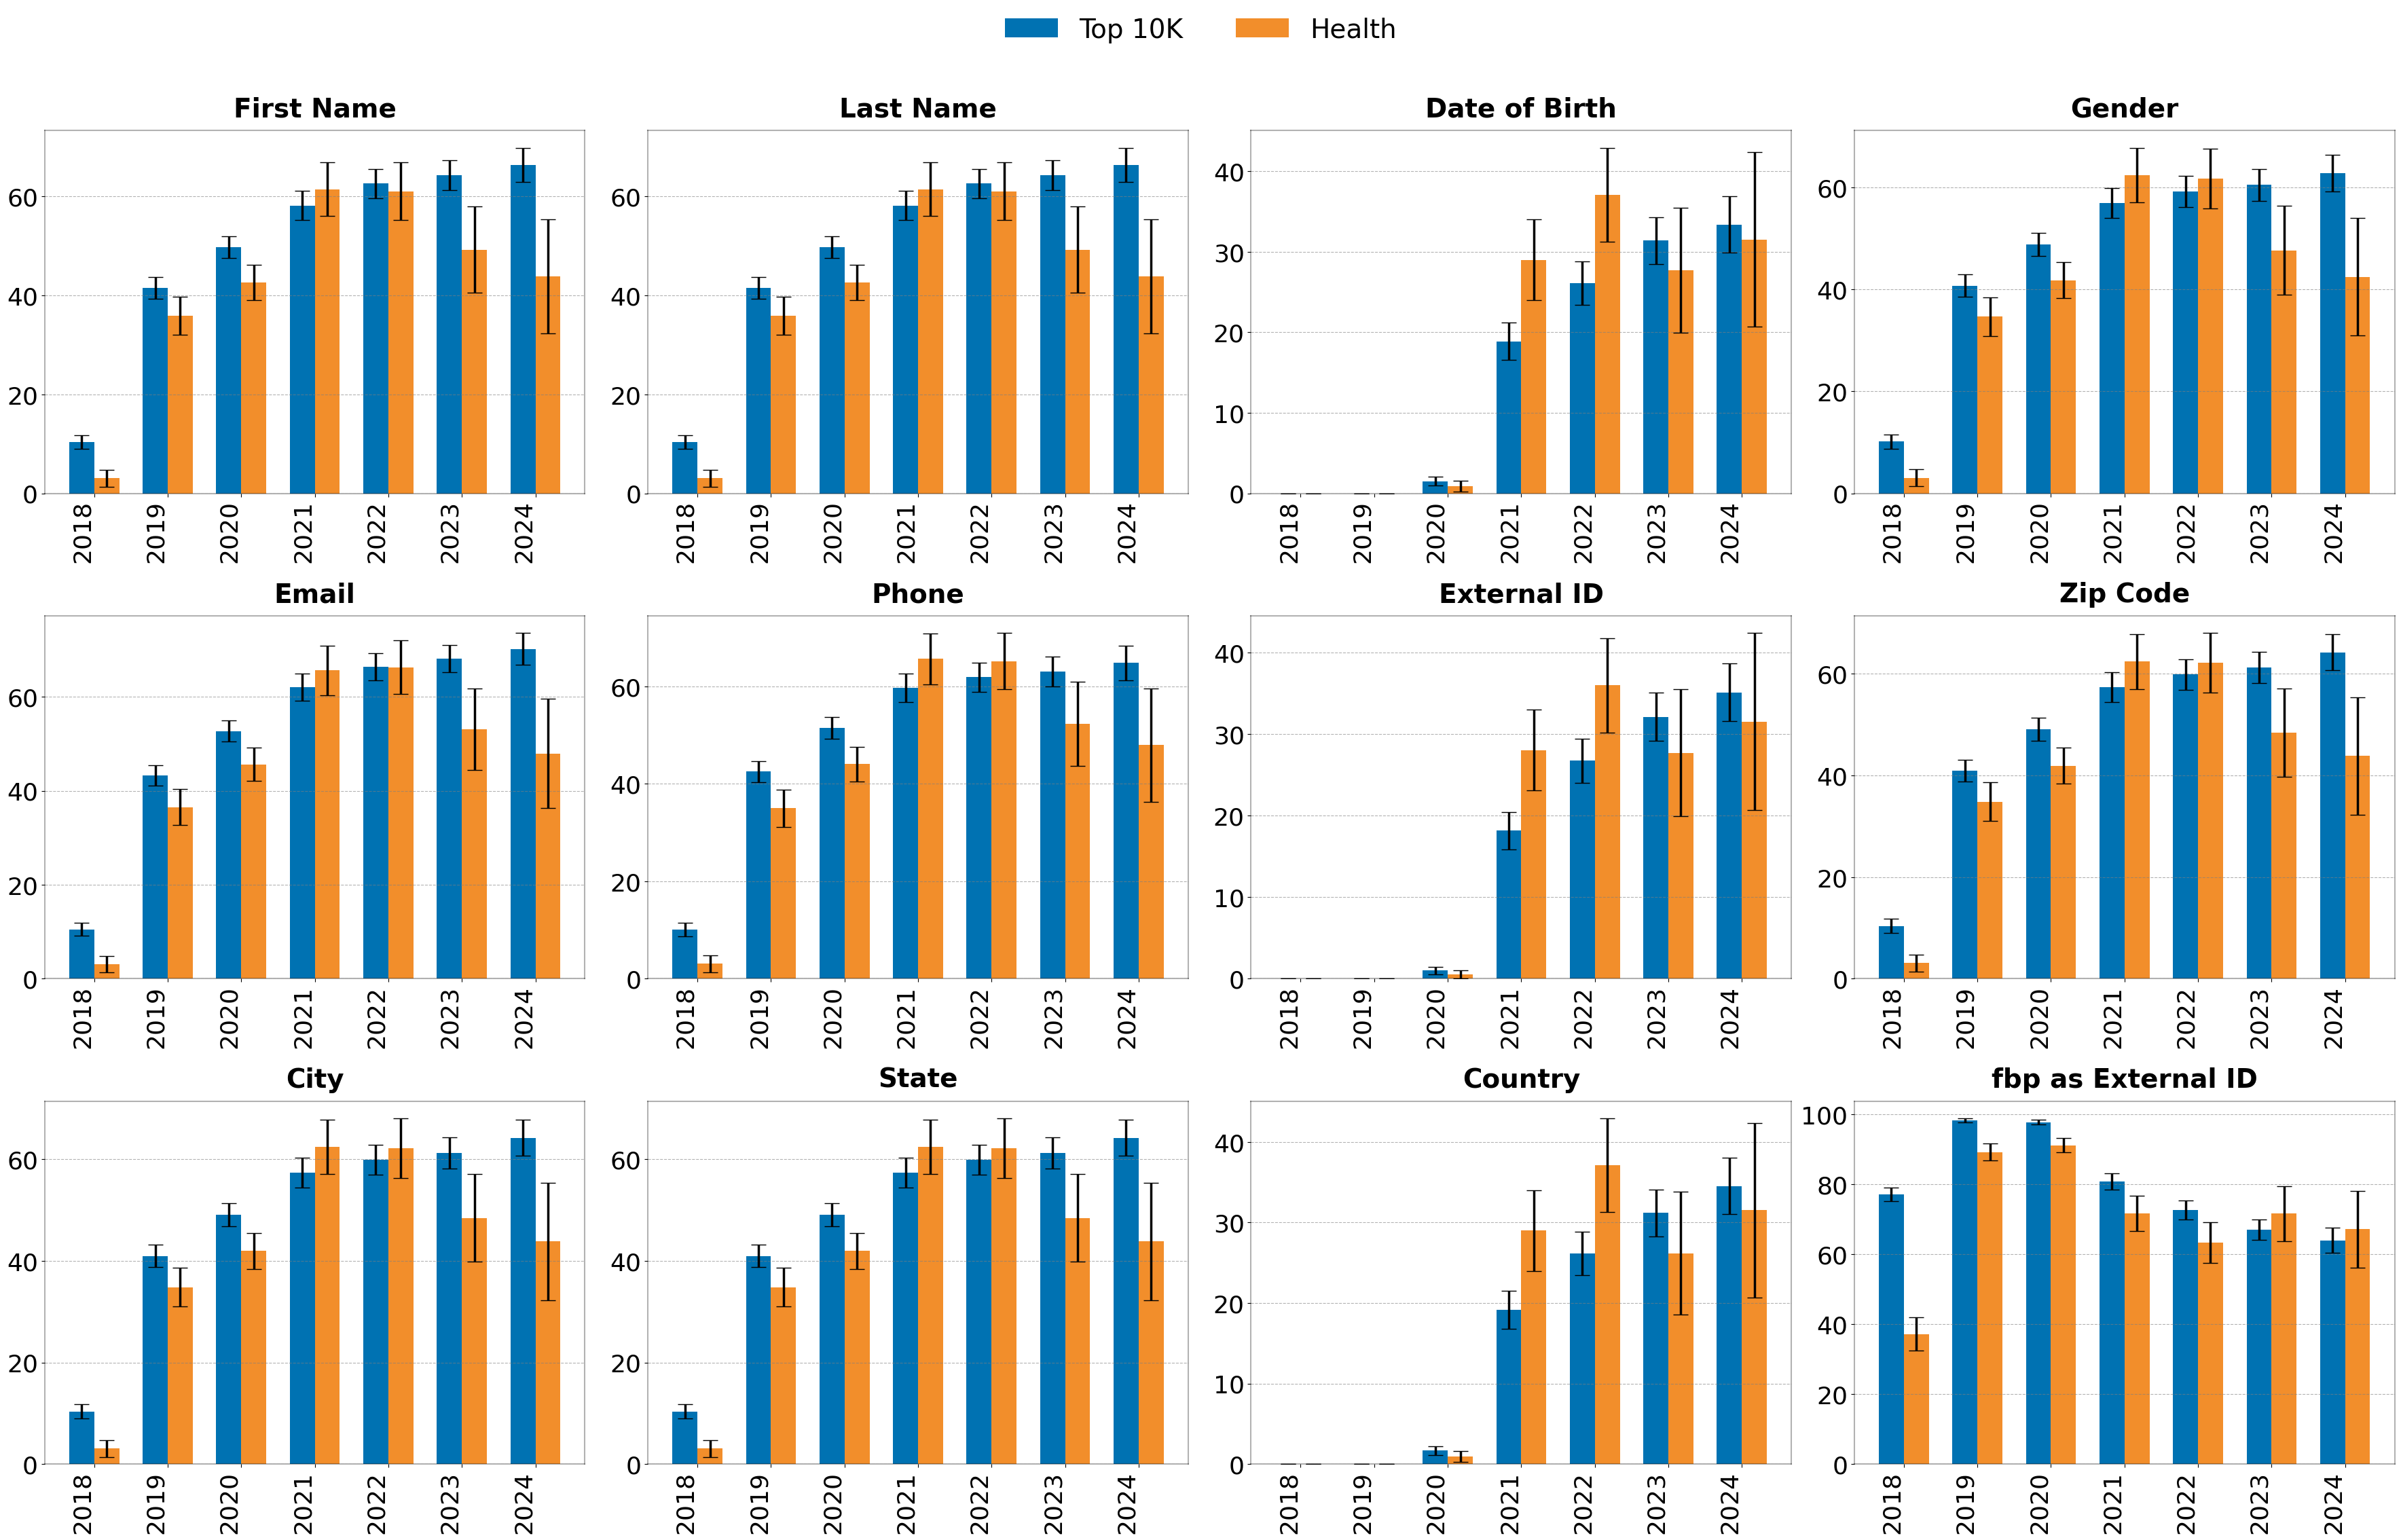

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t
from matplotlib.patches import Rectangle

def visualize_updated_graph(dfs, df_names=None):
    """
    Creates a 3x4 grid of subplots showing:
      - The first 11 subplots: percentages for various keys (derived from config_set_info)
      - The 12th subplot: the percentage of websites using firstpartycookies (from opt_in_info) as external_id.

    A single legend is placed above all subplots.

    Args:
        dfs (list of pd.DataFrame): List of DataFrames containing website data.
        df_names (list of str): Names for each DataFrame (e.g., ['Top 10K', 'Health']).

    Returns:
        None
    """
    # Set default names if none provided
    if df_names is None:
        df_names = [f"DF{i+1}" for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    #### 1. Process configuration file data (config_set_info) ####
    value_presence_list = []      # List of DataFrames for config measure per dataset.
    total_websites_per_year_list = []  # Total website counts (used for error computation)

    for df in dfs:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['year'] = df['timestamp'].dt.to_period('Y')

        total_websites = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()
        total_websites_per_year_list.append(total_websites)

        # Explode and process config_set_info to extract selectedMatchKeys
        df_exploded = df.explode('config_set_info').dropna(subset=['config_set_info'])
        df_exploded[['extracted_config_name', 'config_json']] = pd.DataFrame(
            df_exploded['config_set_info'].tolist(), index=df_exploded.index)

        # Keep only rows where the config file is of interest (e.g. 'automaticmatching')
        df_filtered = df_exploded[df_exploded['extracted_config_name'] == 'automaticmatching'].dropna(subset=['timestamp'])
        df_filtered['selectedMatchKeys'] = df_filtered['config_json'].apply(lambda x: x.get('selectedMatchKeys', []))
        df_keys = df_filtered.explode('selectedMatchKeys', ignore_index=False).fillna({'selectedMatchKeys': 'Empty'})

        # For each website and key, mark True if it appears at least once
        website_value_presence_keys = df_keys.groupby(['year', 'website', 'selectedMatchKeys']).size().unstack(fill_value=0).gt(0)
        value_presence = website_value_presence_keys.groupby('year').sum().div(total_websites, axis=0) * 100
        value_presence_list.append(value_presence)

    # Desired order for the keys (excluding "external_id" for the combined plot)
    desired_order = ['fn', 'ln', 'db', 'ge', 'em', 'ph', 'external_id', 'zp', 'ct', 'st', 'country']
    available_keys = set()
    for vp in value_presence_list:
        available_keys.update(vp.columns)
    ordered_keys = [key for key in desired_order if key in available_keys]

    #### 2. Process opt-in data (opt_in_info) for firstpartycookies ####
    optin_presence_list = []  # List of DataFrames for the opt-in measure.
    total_optin_websites_list = []

    for df in dfs:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['year'] = df['timestamp'].dt.to_period('Y')

        total_websites_optin = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()
        total_optin_websites_list.append(total_websites_optin)

        df_exploded = df.explode('opt_in_info').dropna(subset=['opt_in_info'])
        df_exploded[['extracted_optin_name', 'status']] = pd.DataFrame(
            df_exploded['opt_in_info'].tolist(), index=df_exploded.index)

        df_filtered = df_exploded[df_exploded['extracted_optin_name'] == 'firstpartycookies'].dropna(subset=['timestamp'])
        website_presence_optin = df_filtered.groupby(['year', 'website', 'extracted_optin_name']).size().unstack(fill_value=0).gt(0)
        optin_presence = website_presence_optin.groupby('year').sum().div(total_websites_optin, axis=0) * 100
        optin_presence_list.append(optin_presence)

    #### 3. Compute the combined measure (external_id OR firstpartycookies) ####
    combined_presence_list = []
    for idx in range(len(dfs)):
        vp_website_level = None
        if 'external_id' in value_presence_list[idx].columns:
            df_exploded_config = dfs[idx].explode('config_set_info').dropna(subset=['config_set_info'])
            df_exploded_config[['extracted_config_name', 'config_json']] = pd.DataFrame(
                df_exploded_config['config_set_info'].tolist(), index=df_exploded_config.index)
            df_filtered_config = df_exploded_config[df_exploded_config['extracted_config_name'] == 'automaticmatching'].dropna(subset=['timestamp'])
            df_filtered_config['selectedMatchKeys'] = df_filtered_config['config_json'].apply(lambda x: x.get('selectedMatchKeys', []))
            df_keys_config = df_filtered_config.explode('selectedMatchKeys', ignore_index=False).fillna({'selectedMatchKeys': 'Empty'})
            website_value_presence_keys_website_level = df_keys_config.groupby(['year', 'website', 'selectedMatchKeys']).size().unstack(fill_value=0).gt(0)
            if 'external_id' in website_value_presence_keys_website_level.columns:
                vp_website_level = website_value_presence_keys_website_level[['external_id']]
            else:
                vp_website_level = website_value_presence_keys_website_level.copy()
                vp_website_level['external_id'] = False

        optin_presence_website_level = None
        if 'firstpartycookies' in optin_presence_list[idx].columns:
            df_exploded_optin = dfs[idx].explode('opt_in_info').dropna(subset=['opt_in_info'])
            df_exploded_optin[['extracted_optin_name', 'status']] = pd.DataFrame(
                df_exploded_optin['opt_in_info'].tolist(), index=df_exploded_optin.index)
            df_filtered_optin = df_exploded_optin[df_exploded_optin['extracted_optin_name'] == 'firstpartycookies'].dropna(subset=['timestamp'])
            website_presence_optin_website_level = df_filtered_optin.groupby(['year', 'website', 'extracted_optin_name']).size().unstack(fill_value=0).gt(0)

            if 'firstpartycookies' in website_presence_optin_website_level.columns:
                optin_presence_website_level = website_presence_optin_website_level[['firstpartycookies']]
            else:
                optin_presence_website_level = website_presence_optin_website_level.copy()
                optin_presence_website_level['firstpartycookies'] = False
        else:
            if vp_website_level is not None:
                optin_presence_website_level = vp_website_level.copy()
                optin_presence_website_level['firstpartycookies'] = False
            else:
                combined_presence_list.append(pd.Series(0, index=value_presence_list[idx].index if len(value_presence_list[idx]) > 0 else optin_presence_list[idx].index if len(optin_presence_list[idx]) > 0 else dfs[idx]['year'].unique(), dtype='float64'))
                continue

        if vp_website_level is not None and optin_presence_website_level is not None:
            all_websites = vp_website_level.index.union(optin_presence_website_level.index)
            external_id = vp_website_level.reindex(all_websites, fill_value=False)['external_id']
            firstpartycookies = optin_presence_website_level.reindex(all_websites, fill_value=False)['firstpartycookies']

            combined_website_presence = pd.DataFrame({
                'external_id': external_id,
                'firstpartycookies': firstpartycookies
            })

            combined_website_presence['external_id_only'] = (
                ~combined_website_presence['external_id'] &  # NOT external_id
                combined_website_presence['firstpartycookies']  # AND firstpartycookies
            )

            combined_presence_year = combined_website_presence.groupby('year')['external_id_only'].sum()
            total_websites_year = total_websites_per_year_list[idx]
            combined_percentage = (combined_presence_year.div(total_websites_year, fill_value=0) * 100).fillna(0)
            combined_presence_list.append(combined_percentage)

    # Create the list of keys to plot in the grid.
    grid_keys = ordered_keys + ['Combined (first-party as external)']

    #### 4. Create the 3x4 grid of subplots ####
    fig, axes = plt.subplots(3, 4, figsize=(36, 22))
    axes = axes.flatten()
    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.88, wspace=0.15, hspace=0.4)

    # Style parameters
    colors = ["#0072B2", "#F28E2B"]
    bar_width = 0.425
    group_gap = 0.4

    # Map short key names to nicer titles.
    title_map = {
        'fn': 'First Name',
        'ln': 'Last Name',
        'db': 'Date of Birth',
        'ge': 'Gender',
        'em': 'Email',
        'ph': 'Phone',
        'zp': 'Zip Code',
        'ct': 'City',
        'st': 'State',
        'country': 'Country',
        'external_id': 'External ID',
        'Combined (first-party as external)': 'fbp as External ID'
    }

    alpha = 0.05  # significance level for error bars

    # Initialize handles and labels for the unified legend
    handles = []
    labels = []

    # For each key, plot its values for each DataFrame.
    for idx, key in enumerate(grid_keys):
        ax = axes[idx]
        for spine in ax.spines.values():
            spine.set_alpha(0.3)
            spine.set_linewidth(1.5)

        # Determine all available years (as Period objects) for this key across data sets.
        all_years = set()
        if key != 'Combined (first-party as external)':
            for vp in value_presence_list:
                if key in vp.columns:
                    all_years.update(vp.index.tolist())
        else:
            all_years.update(combined_presence_list[0].index.tolist() if combined_presence_list else dfs[0]['year'].unique())

        sorted_years = sorted(all_years)
        years_str = [str(yr) for yr in sorted_years]

        num_dfs = len(dfs)
        x_positions = [i * (num_dfs * bar_width + group_gap) for i in range(len(sorted_years))]

        for df_idx in range(len(dfs)):
            if key != 'Combined (first-party as external)':
                vp = value_presence_list[df_idx]
                if key not in vp.columns:
                    data = pd.Series(0, index=sorted_years, dtype='float64')
                else:
                    data = vp[key].reindex(sorted_years, fill_value=0)
                total_data = total_websites_per_year_list[df_idx].reindex(sorted_years, fill_value=0)
                error_list = []
                for i, year in enumerate(sorted_years):
                    p = data.iloc[i] / 100.0
                    n = total_data.iloc[i]
                    if n > 1:
                        t_crit = t.ppf(1 - alpha/2, df=n - 1)
                        se = np.sqrt(p * (1 - p) / n)
                        margin = t_crit * se * 100
                    else:
                        margin = 0
                    error_list.append(margin)
                error = np.array(error_list)
            else:
                data = combined_presence_list[df_idx].reindex(sorted_years, fill_value=0)
                total_data = total_websites_per_year_list[df_idx].reindex(sorted_years, fill_value=0)
                error_list = []
                for i, year in enumerate(sorted_years):
                    p = data.iloc[i] / 100.0
                    n = total_data.iloc[i]
                    if n > 1:
                        t_crit = t.ppf(1 - alpha/2, df=n - 1)
                        se = np.sqrt(p * (1 - p) / n)
                        margin = t_crit * se * 100
                    else:
                        margin = 0
                    error_list.append(margin)
                error = np.array(error_list)

            bar_positions = [x + df_idx * bar_width for x in x_positions]
            bars = ax.bar(
                bar_positions,
                data.values,
                width=bar_width,
                color=colors[df_idx % len(colors)],
                label=df_names[df_idx],
                yerr=error,
                error_kw={'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8},
                capsize=5
            )

            # Collect handles/labels from the first subplot only
            if idx == 0:
                handles.append(bars[0])
                labels.append(df_names[df_idx])

        ax.set_title(title_map.get(key, key), fontsize=28, pad=15, weight='bold')
        ax.set_xticks([x + (num_dfs * bar_width - bar_width) / 2 for x in x_positions])
        ax.set_xticklabels(years_str, rotation=90, ha='right', fontsize=26)
        ax.tick_params(axis='y', labelsize=26)
        ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.6)

    # Turn off unused subplots
    for j in range(len(grid_keys), len(axes)):
        axes[j].axis('off')

    # Add unified legend above all subplots
    fig.legend(
        handles, labels,
        loc='upper center',
        ncol=len(dfs),
        # fontsize=28,
        prop={ 'size': 28},  # Bold + fontsize
        bbox_to_anchor=(0.5, 1.05),
        framealpha=0.9,
        frameon=False
    )

    plt.tight_layout(pad=3.0, h_pad=2.0, w_pad=1.0)
    pdf_filename = "plot_AAM.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', transparent=True, dpi=600)
    print(f"Plot saved as {pdf_filename}")
    plt.show()


# Example usage
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()
df1 = df1[(df1['timestamp'] >= '2018-01-01') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2018-01-01') & (df2['timestamp'] < '2025-01-01')]
visualize_updated_graph([df1, df2], df_names=['Top 10K', 'Health'])

#### First Party Cookies

extracted_optin_name,firstpartycookies
year,
2018,77.039955
2019,98.133199
2020,98.697917
2021,98.604651
2022,98.640777
2023,98.765432
2024,98.585573


extracted_optin_name,firstpartycookies
year,
2018,37.150127
2019,89.166667
2020,91.612058
2021,99.681529
2022,99.250936
2023,99.230769
2024,98.630137


Plot saved as plot_firstpartycookies.pdf


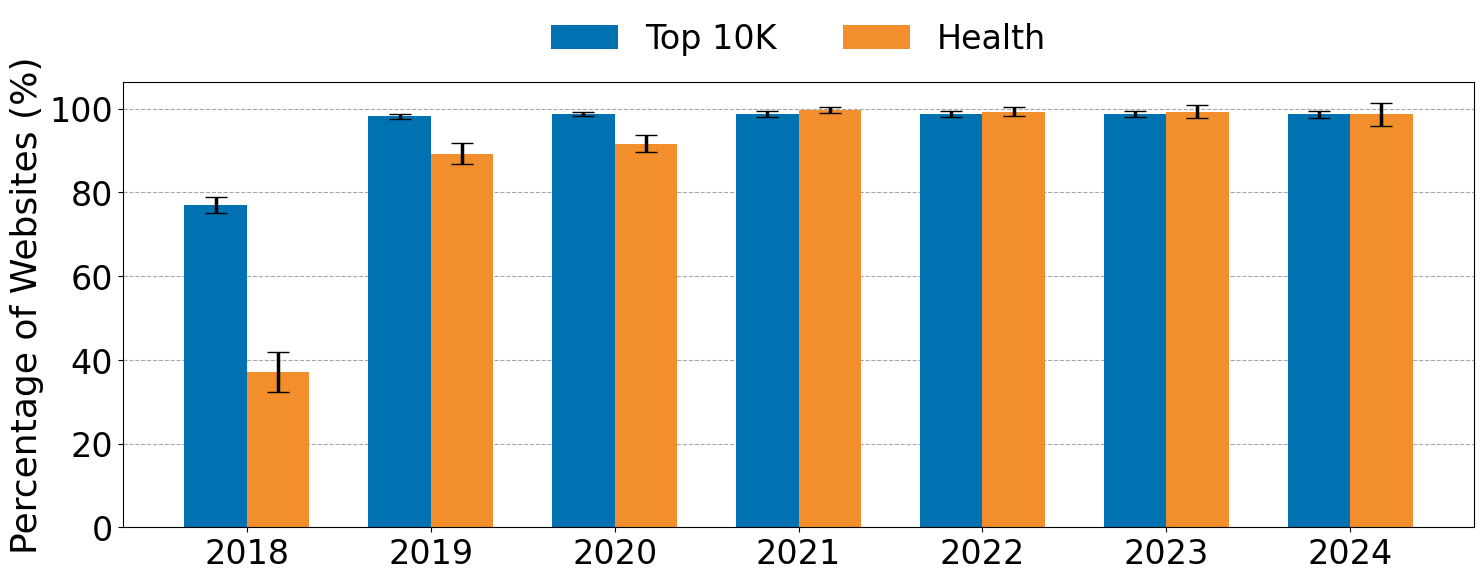

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t  # For t-distribution critical values

def visualize_selected_match_keys_percentage_heatmap_grouped_styled(dfs, df_names=None):
  
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    value_presence_per_website_list = []
    error_presence_per_website_list = []  # List to store t-based error margins

    for df in dfs:
        # Ensure timestamp is datetime and extract period info
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['month'] = df['timestamp'].dt.to_period('M')
        df['year'] = df['timestamp'].dt.to_period('Y')

        # Compute total number of unique websites per year
        total_websites_per_year = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()

        # Explode the opt-in list and extract details
        df_exploded = df.explode('opt_in_info').dropna(subset=['opt_in_info'])
        df_exploded[['extracted_optin_name', 'status']] = pd.DataFrame(
            df_exploded['opt_in_info'].tolist(), index=df_exploded.index
        )

        # Filter for the key 'firstpartycookies' and remove rows with missing timestamps
        df_filtered = df_exploded[df_exploded['extracted_optin_name'] == 'firstpartycookies'].dropna(subset=['timestamp'])
        website_value_presence = (
            df_filtered.groupby(['year','website','extracted_optin_name'])
            .size()
            .unstack(fill_value=0)
            .gt(0)
            .groupby('year')
            .sum()
        )

        # Calculate the percentage of websites using the key
        value_presence_per_website = website_value_presence.groupby('year').sum().div(total_websites_per_year, axis=0) * 100
        value_presence_per_website_list.append(value_presence_per_website)
        display(value_presence_per_website)

        # Calculate error bars using t-distribution for each year and key
        error_df = value_presence_per_website.copy()
        for year in error_df.index:
            n = total_websites_per_year.loc[year]
            # Iterate through each key (column)
            for key in error_df.columns:
                # Get the proportion p (as a fraction) for the year and key
                p = value_presence_per_website.loc[year, key] / 100.0
                # If sample size is too small, set error to 0
                if n <= 1:
                    margin = 0
                else:
                    t_val = t.ppf(1 - 0.05/2, df=n-1)
                    margin = t_val * np.sqrt(p * (1 - p) / n) * 100
                error_df.loc[year, key] = margin
        error_presence_per_website_list.append(error_df)

    # Get all unique keys from all DataFrames
    all_keys = set()
    for vp_df in value_presence_per_website_list:
        all_keys.update(vp_df.columns)
    all_keys = sorted(list(all_keys))  # Sorted for consistency

    # --- Style Customizations ---
    plt.rcParams['figure.figsize'] = (15, 6)      # Wider figure
    plt.rcParams['font.size'] = 12                # Base font size
    plt.rcParams['axes.labelsize'] = 20           # Axis label font size
    plt.rcParams['axes.titlesize'] = 16           # Axis title font size
    plt.rcParams['xtick.labelsize'] = 24          # X tick label font size
    plt.rcParams['ytick.labelsize'] = 24          # Y tick label font size
    plt.rcParams['legend.fontsize'] = 24          # Legend font size

    # Colors and hatches for each dataset
    colors = ["#99d594", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
    colors = ["#0072B2", "#F28E2B"]

    hatches = ["..", "//", "\\\\", "xx", "oo", "OO", "..", "**"]

    # Plotting section for each key
    num_dfs = len(dfs)
    bar_width = 0.8 / num_dfs  # Adjust bar width to fit groups
    group_gap = 0.4            # Gap between year groups
    bar_width = 0.425

    for key in all_keys:
        fig, ax = plt.subplots()  # Create a new figure for each key

        # Get a union of all years (as strings) across the datasets
        year_strings_lists = [
            vp_df.index.astype(str).tolist() if vp_df is not None and vp_df.index is not None else []
            for vp_df in value_presence_per_website_list
        ]
        unique_year_strings = sorted(list(set().union(*year_strings_lists)))
        years = unique_year_strings  # Use string years for plotting

        if not years:
            continue  # Skip if no years to plot

        # Calculate x positions for each year group
        x_positions = [i * (num_dfs * bar_width + group_gap) for i in range(len(years))]

        for df_index, (vp_df, err_df) in enumerate(zip(value_presence_per_website_list, error_presence_per_website_list)):
            if vp_df is None:
                continue

            # Reindex to ensure consistency across years
            if key in vp_df.columns:
                data_key = vp_df[key].reindex(index=years, fill_value=0)
                error_key = err_df[key].reindex(index=years, fill_value=0)
            else:
                data_key = pd.Series(0, index=years, dtype='float64')
                error_key = pd.Series(0, index=years, dtype='float64')


            error_kw = {'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8}

            # Calculate the bar positions for this dataset
            bar_positions = [pos + df_index * bar_width for pos in x_positions]
            ax.bar(
                bar_positions,
                data_key.values,
                width=bar_width,
                label=df_names[df_index],
                color=colors[df_index % len(colors)],  # Cycle through colors
                # edgecolor="black",  # Black border around bars
                # hatch=hatches[df_index % len(hatches)],  # Cycle through hatches
                yerr=error_key.values,  # Add t-distribution based error bars
                capsize=5,  # Caps on error bars
                error_kw = error_kw
            )

        # --- Formatting ---
        ax.set_ylabel("Percentage of Websites (%)", fontsize=26)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

        # Center x-tick labels under each group of bars
        xticks_positions = [pos + (num_dfs * bar_width - bar_width) / 2 for pos in x_positions]
        ax.set_xticks(xticks_positions)
        ax.set_xticklabels(years, rotation=0)



        ax.legend(loc="upper center",bbox_to_anchor=(0.5, 1.2), ncol=num_dfs,frameon=False)
        plt.tight_layout()

        pdf_filename = "plot_firstpartycookies.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', 
                transparent=True)  # Keep transparency in PDF
        
        print(f"Plot saved as {pdf_filename}")
        plt.show()
        plt.show()

    return value_presence_per_website_list, error_presence_per_website_list

# Replace these with your actual DataFrames if needed
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

df1 = df1[(df1['timestamp'] >= '2018-01-01') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2018-01-01') & (df2['timestamp'] < '2025-01-01')]

# Assuming you have loaded your DataFrames into top10k_websites, hospital_websites, kids_websites
result_dfs, result_errors = visualize_selected_match_keys_percentage_heatmap_grouped_styled(
    [df1, df2],
    df_names=['Top 10K', 'Health']
)


#### Automatic Matching (as a feature)

extracted_optin_name,automaticmatching
year,
2018,10.523354
2019,43.289606
2020,52.760417
2021,62.232558
2022,66.699029
2023,68.415638
2024,70.155587


Average:  53.43945560075021


extracted_optin_name,automaticmatching
year,
2018,3.053435
2019,36.666667
2020,46.264744
2021,66.560510
2022,67.790262
2023,53.076923
2024,47.945205


Average:  45.90824949912178
Plot saved as plot_automaticmatching.pdf


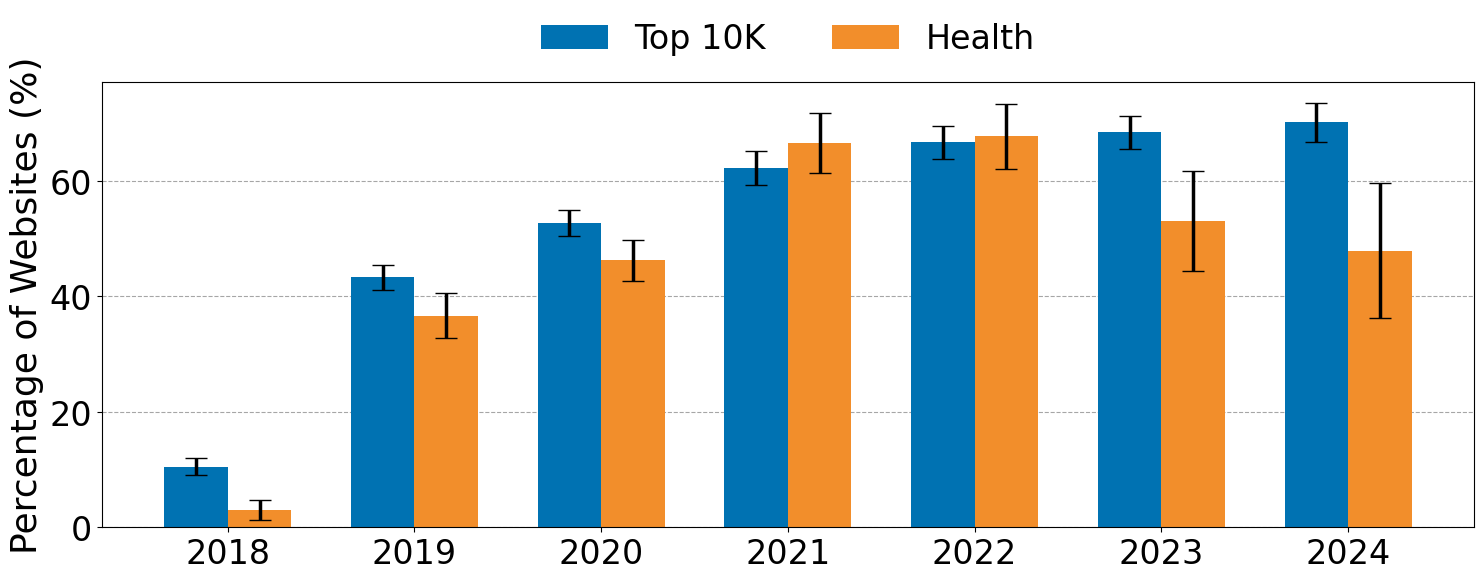

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t  # For t-distribution critical values

def visualize_selected_match_keys_percentage_heatmap_grouped_styled(dfs, df_names=None):
  
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    value_presence_per_website_list = []
    error_presence_per_website_list = []  # List to store t-based error margins

    for df in dfs:
        # Ensure timestamp is datetime and extract period info
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['month'] = df['timestamp'].dt.to_period('M')
        df['year'] = df['timestamp'].dt.to_period('Y')

        # Compute total number of unique websites per year
        total_websites_per_year = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()

        # Explode the opt-in list and extract details
        df_exploded = df.explode('opt_in_info').dropna(subset=['opt_in_info'])
        df_exploded[['extracted_optin_name', 'status']] = pd.DataFrame(
            df_exploded['opt_in_info'].tolist(), index=df_exploded.index
        )

        # Filter for the key 'firstpartycookies' and remove rows with missing timestamps
        df_filtered = df_exploded[df_exploded['extracted_optin_name'] == 'automaticmatching'].dropna(subset=['timestamp'])
        website_value_presence = (
            df_filtered.groupby(['year','website','extracted_optin_name'])
            .size()
            .unstack(fill_value=0)
            .gt(0)
            .groupby('year')
            .sum()
        )

        # Calculate the percentage of websites using the key
        value_presence_per_website = website_value_presence.groupby('year').sum().div(total_websites_per_year, axis=0) * 100
        value_presence_per_website_list.append(value_presence_per_website)
        display(value_presence_per_website)
        print("Average: ",np.average(value_presence_per_website['automaticmatching']))

        # Calculate error bars using t-distribution for each year and key
        error_df = value_presence_per_website.copy()
        for year in error_df.index:
            n = total_websites_per_year.loc[year]
            # Iterate through each key (column)
            for key in error_df.columns:
                # Get the proportion p (as a fraction) for the year and key
                p = value_presence_per_website.loc[year, key] / 100.0
                # If sample size is too small, set error to 0
                if n <= 1:
                    margin = 0
                else:
                    t_val = t.ppf(1 - 0.05/2, df=n-1)
                    margin = t_val * np.sqrt(p * (1 - p) / n) * 100
                error_df.loc[year, key] = margin
        error_presence_per_website_list.append(error_df)

    # Get all unique keys from all DataFrames
    all_keys = set()
    for vp_df in value_presence_per_website_list:
        all_keys.update(vp_df.columns)
    all_keys = sorted(list(all_keys))  # Sorted for consistency

    # --- Style Customizations ---
    plt.rcParams['figure.figsize'] = (15, 6)      # Wider figure
    plt.rcParams['font.size'] = 12                # Base font size
    plt.rcParams['axes.labelsize'] = 20           # Axis label font size
    plt.rcParams['axes.titlesize'] = 16           # Axis title font size
    plt.rcParams['xtick.labelsize'] = 24          # X tick label font size
    plt.rcParams['ytick.labelsize'] = 24          # Y tick label font size
    plt.rcParams['legend.fontsize'] = 24          # Legend font size

    # Colors and hatches for each dataset
    colors = ["#99d594", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
    colors = ["#0072B2", "#F28E2B"]

    hatches = ["..", "//", "\\\\", "xx", "oo", "OO", "..", "**"]

    # Plotting section for each key
    num_dfs = len(dfs)
    bar_width = 0.8 / num_dfs  # Adjust bar width to fit groups
    group_gap = 0.4            # Gap between year groups
    bar_width = 0.425

    for key in all_keys:
        fig, ax = plt.subplots()  # Create a new figure for each key

        # Get a union of all years (as strings) across the datasets
        year_strings_lists = [
            vp_df.index.astype(str).tolist() if vp_df is not None and vp_df.index is not None else []
            for vp_df in value_presence_per_website_list
        ]
        unique_year_strings = sorted(list(set().union(*year_strings_lists)))
        years = unique_year_strings  # Use string years for plotting

        if not years:
            continue  # Skip if no years to plot

        # Calculate x positions for each year group
        x_positions = [i * (num_dfs * bar_width + group_gap) for i in range(len(years))]

        for df_index, (vp_df, err_df) in enumerate(zip(value_presence_per_website_list, error_presence_per_website_list)):
            if vp_df is None:
                continue

            # Reindex to ensure consistency across years
            if key in vp_df.columns:
                data_key = vp_df[key].reindex(index=years, fill_value=0)
                error_key = err_df[key].reindex(index=years, fill_value=0)
            else:
                data_key = pd.Series(0, index=years, dtype='float64')
                error_key = pd.Series(0, index=years, dtype='float64')


            error_kw = {'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8}

            # Calculate the bar positions for this dataset
            bar_positions = [pos + df_index * bar_width for pos in x_positions]
            ax.bar(
                bar_positions,
                data_key.values,
                width=bar_width,
                label=df_names[df_index],
                color=colors[df_index % len(colors)],  # Cycle through colors
                # edgecolor="black",  # Black border around bars
                # hatch=hatches[df_index % len(hatches)],  # Cycle through hatches
                yerr=error_key.values,  # Add t-distribution based error bars
                capsize=5,  # Caps on error bars
                error_kw = error_kw
            )

        # --- Formatting ---
        ax.set_ylabel("Percentage of Websites (%)", fontsize=26)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

        # Center x-tick labels under each group of bars
        xticks_positions = [pos + (num_dfs * bar_width - bar_width) / 2 for pos in x_positions]
        ax.set_xticks(xticks_positions)
        ax.set_xticklabels(years, rotation=0)



        ax.legend(loc="upper center",bbox_to_anchor=(0.5, 1.2), ncol=num_dfs,frameon=False)
        plt.tight_layout()

        pdf_filename = "plot_automaticmatching.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', 
                transparent=True)  # Keep transparency in PDF
        
        print(f"Plot saved as {pdf_filename}")
        plt.show()
        plt.show()

    return value_presence_per_website_list, error_presence_per_website_list

# Replace these with your actual DataFrames if needed
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

df1 = df1[(df1['timestamp'] >= '2018-01-01') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2018-01-01') & (df2['timestamp'] < '2025-01-01')]

# Assuming you have loaded your DataFrames into top10k_websites, hospital_websites, kids_websites
result_dfs, result_errors = visualize_selected_match_keys_percentage_heatmap_grouped_styled(
    [df1, df2],
    df_names=['Top 10K', 'Health']
)


### EstRules (as a feature)

extracted_optin_name,estruleengine
year,
2018,NaN
2019,NaN
2020,NaN
2021,NaN
2022,NaN
2023,83.230453
2024,50.212164


Average:  nan


extracted_optin_name,estruleengine
year,
2018,NaN
2019,NaN
2020,NaN
2021,NaN
2022,NaN
2023,75.384615
2024,58.904110


Average:  nan


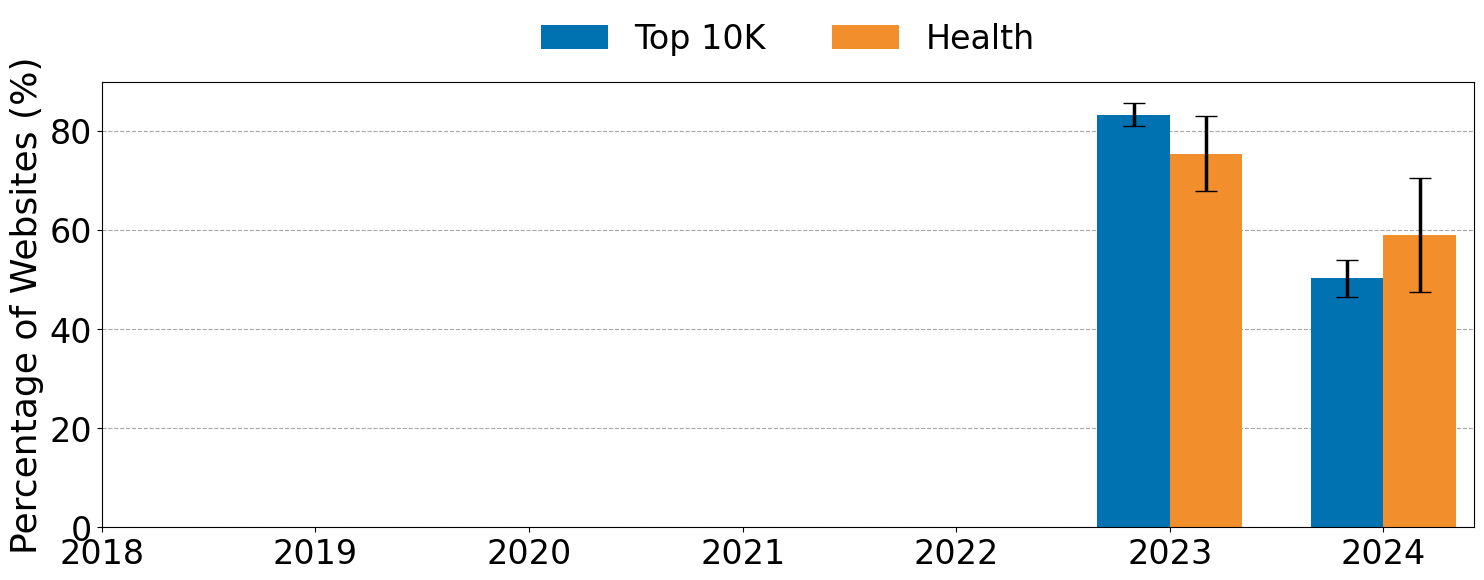

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t  # For t-distribution critical values

def visualize_selected_match_keys_percentage_heatmap_grouped_styled(dfs, df_names=None):
  
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    value_presence_per_website_list = []
    error_presence_per_website_list = []  # List to store t-based error margins

    for df in dfs:
        # Ensure timestamp is datetime and extract period info
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['month'] = df['timestamp'].dt.to_period('M')
        df['year'] = df['timestamp'].dt.to_period('Y')

        # Compute total number of unique websites per year
        total_websites_per_year = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()

        # Explode the opt-in list and extract details
        df_exploded = df.explode('opt_in_info').dropna(subset=['opt_in_info'])
        df_exploded[['extracted_optin_name', 'status']] = pd.DataFrame(
            df_exploded['opt_in_info'].tolist(), index=df_exploded.index
        )

        # Filter for the key 'firstpartycookies' and remove rows with missing timestamps
        df_filtered = df_exploded[df_exploded['extracted_optin_name'] == 'estruleengine'].dropna(subset=['timestamp'])
        website_value_presence = (
            df_filtered.groupby(['year','website','extracted_optin_name'])
            .size()
            .unstack(fill_value=0)
            .gt(0)
            .groupby('year')
            .sum()
        )

        # Calculate the percentage of websites using the key
        value_presence_per_website = website_value_presence.groupby('year').sum().div(total_websites_per_year, axis=0) * 100
        value_presence_per_website_list.append(value_presence_per_website)
        display(value_presence_per_website)
        print("Average: ",np.average(value_presence_per_website['estruleengine']))

        # Calculate error bars using t-distribution for each year and key
        error_df = value_presence_per_website.copy()
        for year in error_df.index:
            n = total_websites_per_year.loc[year]
            # Iterate through each key (column)
            for key in error_df.columns:
                # Get the proportion p (as a fraction) for the year and key
                p = value_presence_per_website.loc[year, key] / 100.0
                # If sample size is too small, set error to 0
                if n <= 1:
                    margin = 0
                else:
                    t_val = t.ppf(1 - 0.05/2, df=n-1)
                    margin = t_val * np.sqrt(p * (1 - p) / n) * 100
                error_df.loc[year, key] = margin
        error_presence_per_website_list.append(error_df)

    # Get all unique keys from all DataFrames
    all_keys = set()
    for vp_df in value_presence_per_website_list:
        all_keys.update(vp_df.columns)
    all_keys = sorted(list(all_keys))  # Sorted for consistency

    # --- Style Customizations ---
    plt.rcParams['figure.figsize'] = (15, 6)      # Wider figure
    plt.rcParams['font.size'] = 12                # Base font size
    plt.rcParams['axes.labelsize'] = 20           # Axis label font size
    plt.rcParams['axes.titlesize'] = 16           # Axis title font size
    plt.rcParams['xtick.labelsize'] = 24          # X tick label font size
    plt.rcParams['ytick.labelsize'] = 24          # Y tick label font size
    plt.rcParams['legend.fontsize'] = 24          # Legend font size

    # Colors and hatches for each dataset
    colors = ["#99d594", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
    colors = ["#0072B2", "#F28E2B"]

    hatches = ["..", "//", "\\\\", "xx", "oo", "OO", "..", "**"]

    # Plotting section for each key
    num_dfs = len(dfs)
    bar_width = 0.8 / num_dfs  # Adjust bar width to fit groups
    group_gap = 0.4            # Gap between year groups
    bar_width = 0.425

    for key in all_keys:
        fig, ax = plt.subplots()  # Create a new figure for each key

        # Get a union of all years (as strings) across the datasets
        year_strings_lists = [
            vp_df.index.astype(str).tolist() if vp_df is not None and vp_df.index is not None else []
            for vp_df in value_presence_per_website_list
        ]
        unique_year_strings = sorted(list(set().union(*year_strings_lists)))
        years = unique_year_strings  # Use string years for plotting

        if not years:
            continue  # Skip if no years to plot

        # Calculate x positions for each year group
        x_positions = [i * (num_dfs * bar_width + group_gap) for i in range(len(years))]

        for df_index, (vp_df, err_df) in enumerate(zip(value_presence_per_website_list, error_presence_per_website_list)):
            if vp_df is None:
                continue

            # Reindex to ensure consistency across years
            if key in vp_df.columns:
                data_key = vp_df[key].reindex(index=years, fill_value=0)
                error_key = err_df[key].reindex(index=years, fill_value=0)
            else:
                data_key = pd.Series(0, index=years, dtype='float64')
                error_key = pd.Series(0, index=years, dtype='float64')


            error_kw = {'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8}

            # Calculate the bar positions for this dataset
            bar_positions = [pos + df_index * bar_width for pos in x_positions]
            ax.bar(
                bar_positions,
                data_key.values,
                width=bar_width,
                label=df_names[df_index],
                color=colors[df_index % len(colors)],  # Cycle through colors
                # edgecolor="black",  # Black border around bars
                # hatch=hatches[df_index % len(hatches)],  # Cycle through hatches
                yerr=error_key.values,  # Add t-distribution based error bars
                capsize=5,  # Caps on error bars
                error_kw = error_kw
            )

        # --- Formatting ---
        ax.set_ylabel("Percentage of Websites (%)", fontsize=26)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

        # Center x-tick labels under each group of bars
        xticks_positions = [pos + (num_dfs * bar_width - bar_width) / 2 for pos in x_positions]
        ax.set_xticks(xticks_positions)
        ax.set_xticklabels(years, rotation=0)



        ax.legend(loc="upper center",bbox_to_anchor=(0.5, 1.2), ncol=num_dfs,frameon=False)
        plt.tight_layout()

        # pdf_filename = "plot_estrules.pdf"
        # plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', 
        #         transparent=True)  # Keep transparency in PDF
        
        # print(f"Plot saved as {pdf_filename}")
        plt.show()
        plt.show()

    return value_presence_per_website_list, error_presence_per_website_list

# Replace these with your actual DataFrames if needed
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

df1 = df1[(df1['timestamp'] >= '2018-01-01') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2018-01-01') & (df2['timestamp'] < '2025-01-01')]

# Assuming you have loaded your DataFrames into top10k_websites, hospital_websites, kids_websites
result_dfs, result_errors = visualize_selected_match_keys_percentage_heatmap_grouped_styled(
    [df1, df2],
    df_names=['Top 10K', 'Health']
)


#### Automatic Setup

Plot saved as plot_automaticsetup.pdf


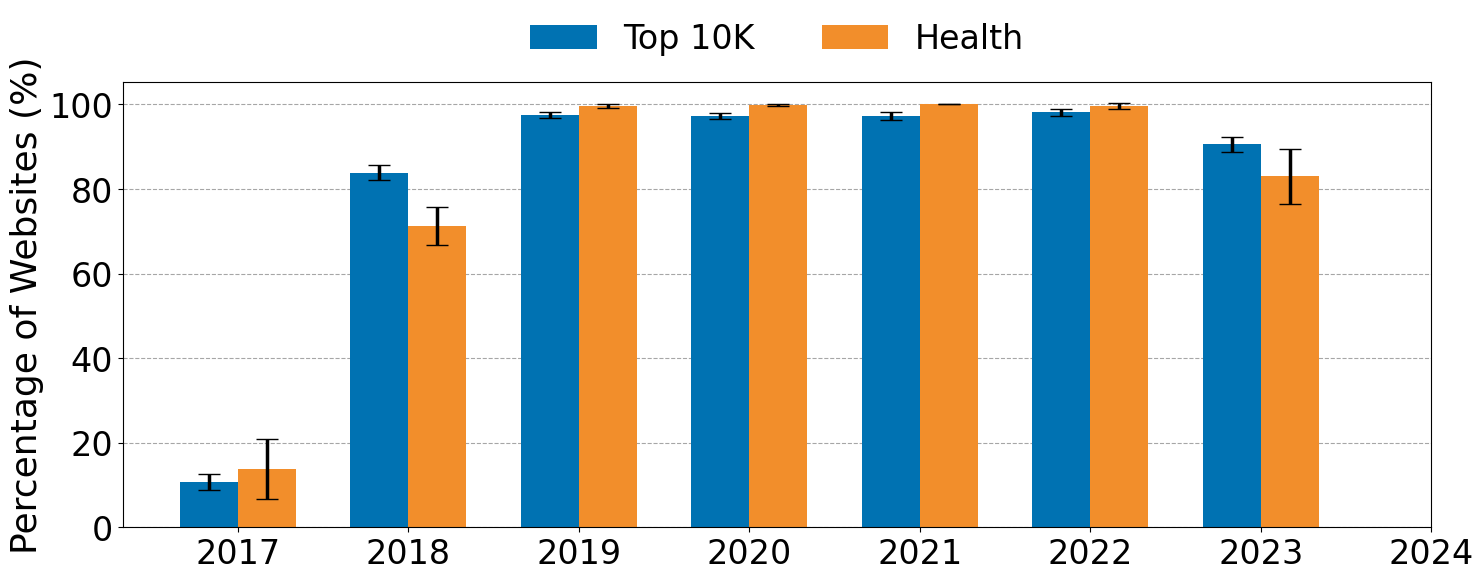

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t  # For t-distribution critical values

def visualize_selected_match_keys_percentage_heatmap_grouped_styled(dfs, df_names=None):
  
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    value_presence_per_website_list = []
    error_presence_per_website_list = []  # List to store t-based error margins

    for df in dfs:
        # Ensure timestamp is datetime and extract period info
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['month'] = df['timestamp'].dt.to_period('M')
        df['year'] = df['timestamp'].dt.to_period('Y')

        # Compute total number of unique websites per year
        total_websites_per_year = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()

        # Explode the opt-in list and extract details
        df_exploded = df.explode('opt_in_info').dropna(subset=['opt_in_info'])
        df_exploded[['extracted_optin_name', 'status']] = pd.DataFrame(
            df_exploded['opt_in_info'].tolist(), index=df_exploded.index
        )

        # Filter for the key 'firstpartycookies' and remove rows with missing timestamps
        df_filtered = df_exploded[df_exploded['extracted_optin_name'] == 'automaticsetup'].dropna(subset=['timestamp'])
        website_value_presence = (
            df_filtered.groupby(['year','website','extracted_optin_name'])
            .size()
            .unstack(fill_value=0)
            .gt(0)
            .groupby('year')
            .sum()
        )

        # Calculate the percentage of websites using the key
        value_presence_per_website = website_value_presence.groupby('year').sum().div(total_websites_per_year, axis=0) * 100
        value_presence_per_website_list.append(value_presence_per_website)
        # display(value_presence_per_website)
        # print("Average: ",np.average(value_presence_per_website['automaticmatching']))

        # Calculate error bars using t-distribution for each year and key
        error_df = value_presence_per_website.copy()
        for year in error_df.index:
            n = total_websites_per_year.loc[year]
            # Iterate through each key (column)
            for key in error_df.columns:
                # Get the proportion p (as a fraction) for the year and key
                p = value_presence_per_website.loc[year, key] / 100.0
                # If sample size is too small, set error to 0
                if n <= 1:
                    margin = 0
                else:
                    t_val = t.ppf(1 - 0.05/2, df=n-1)
                    margin = t_val * np.sqrt(p * (1 - p) / n) * 100
                error_df.loc[year, key] = margin
        error_presence_per_website_list.append(error_df)

    # Get all unique keys from all DataFrames
    all_keys = set()
    for vp_df in value_presence_per_website_list:
        all_keys.update(vp_df.columns)
    all_keys = sorted(list(all_keys))  # Sorted for consistency

    # --- Style Customizations ---
    plt.rcParams['figure.figsize'] = (15, 6)      # Wider figure
    plt.rcParams['font.size'] = 12                # Base font size
    plt.rcParams['axes.labelsize'] = 20           # Axis label font size
    plt.rcParams['axes.titlesize'] = 16           # Axis title font size
    plt.rcParams['xtick.labelsize'] = 24          # X tick label font size
    plt.rcParams['ytick.labelsize'] = 24          # Y tick label font size
    plt.rcParams['legend.fontsize'] = 24          # Legend font size

    # Colors and hatches for each dataset
    colors = ["#99d594", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
    colors = ["#0072B2", "#F28E2B"]

    hatches = ["..", "//", "\\\\", "xx", "oo", "OO", "..", "**"]

    # Plotting section for each key
    num_dfs = len(dfs)
    bar_width = 0.8 / num_dfs  # Adjust bar width to fit groups
    group_gap = 0.4            # Gap between year groups
    bar_width = 0.425

    for key in all_keys:
        fig, ax = plt.subplots()  # Create a new figure for each key

        # Get a union of all years (as strings) across the datasets
        year_strings_lists = [
            vp_df.index.astype(str).tolist() if vp_df is not None and vp_df.index is not None else []
            for vp_df in value_presence_per_website_list
        ]
        unique_year_strings = sorted(list(set().union(*year_strings_lists)))
        years = unique_year_strings  # Use string years for plotting

        if not years:
            continue  # Skip if no years to plot

        # Calculate x positions for each year group
        x_positions = [i * (num_dfs * bar_width + group_gap) for i in range(len(years))]

        for df_index, (vp_df, err_df) in enumerate(zip(value_presence_per_website_list, error_presence_per_website_list)):
            if vp_df is None:
                continue

            # Reindex to ensure consistency across years
            if key in vp_df.columns:
                data_key = vp_df[key].reindex(index=years, fill_value=0)
                error_key = err_df[key].reindex(index=years, fill_value=0)
            else:
                data_key = pd.Series(0, index=years, dtype='float64')
                error_key = pd.Series(0, index=years, dtype='float64')


            error_kw = {'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8}

            # Calculate the bar positions for this dataset
            bar_positions = [pos + df_index * bar_width for pos in x_positions]
            ax.bar(
                bar_positions,
                data_key.values,
                width=bar_width,
                label=df_names[df_index],
                color=colors[df_index % len(colors)],  # Cycle through colors
                # edgecolor="black",  # Black border around bars
                # hatch=hatches[df_index % len(hatches)],  # Cycle through hatches
                yerr=error_key.values,  # Add t-distribution based error bars
                capsize=5,  # Caps on error bars
                error_kw = error_kw
            )

        # --- Formatting ---
        ax.set_ylabel("Percentage of Websites (%)", fontsize=26)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

        # Center x-tick labels under each group of bars
        xticks_positions = [pos + (num_dfs * bar_width - bar_width) / 2 for pos in x_positions]
        ax.set_xticks(xticks_positions)
        ax.set_xticklabels(years, rotation=0)



        ax.legend(loc="upper center",bbox_to_anchor=(0.5, 1.2), ncol=num_dfs,frameon=False)
        plt.tight_layout()

        pdf_filename = "plot_automaticsetup.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', 
                transparent=True)  # Keep transparency in PDF
        
        print(f"Plot saved as {pdf_filename}")
        plt.show()
        plt.show()

    return value_presence_per_website_list, error_presence_per_website_list

# Replace these with your actual DataFrames if needed
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

df1 = df1[(df1['timestamp'] >= '2017-05-01') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2017-05-01') & (df2['timestamp'] < '2025-01-01')]

# Assuming you have loaded your DataFrames into top10k_websites, hospital_websites, kids_websites
result_dfs, result_errors = visualize_selected_match_keys_percentage_heatmap_grouped_styled(
    [df1, df2],
    df_names=['Top 10K', 'Health']
)


### Inferred Events

extracted_optin_name,inferredevents
year,
2017,97.455231
2018,97.692741
2019,97.376387
2020,97.291667
2021,97.302326
2022,98.155340
2023,98.045267
2024,96.322489


extracted_optin_name,inferredevents
year,
2017,97.872340
2018,100.000000
2019,98.333333
2020,99.868938
2021,100.000000
2022,99.625468
2023,88.461538
2024,76.712329


Plot saved as plot_inferredevents.pdf


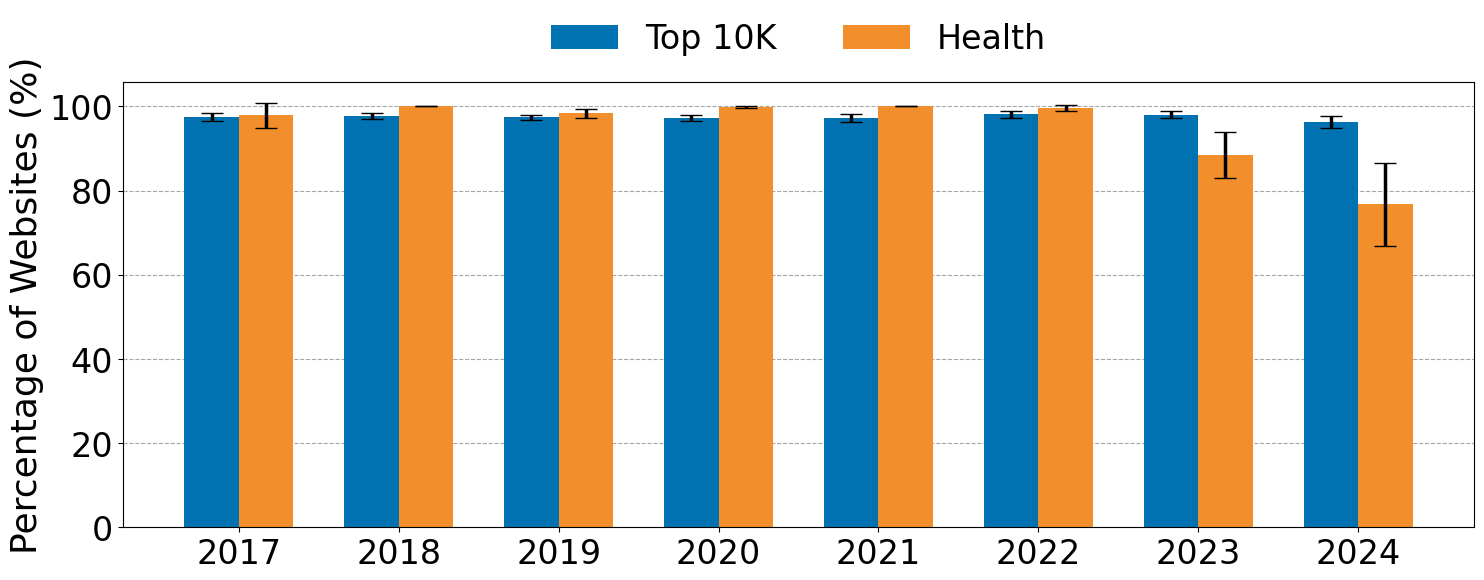

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t  # For t-distribution critical values

def visualize_selected_match_keys_percentage_heatmap_grouped_styled(dfs, df_names=None):
  
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    value_presence_per_website_list = []
    error_presence_per_website_list = []  # List to store t-based error margins

    for df in dfs:
        # Ensure timestamp is datetime and extract period info
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['month'] = df['timestamp'].dt.to_period('M')
        df['year'] = df['timestamp'].dt.to_period('Y')

        # Compute total number of unique websites per year
        total_websites_per_year = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()

        # Explode the opt-in list and extract details
        df_exploded = df.explode('opt_in_info').dropna(subset=['opt_in_info'])
        df_exploded[['extracted_optin_name', 'status']] = pd.DataFrame(
            df_exploded['opt_in_info'].tolist(), index=df_exploded.index
        )

        # Filter for the key 'firstpartycookies' and remove rows with missing timestamps
        df_filtered = df_exploded[df_exploded['extracted_optin_name'] == 'inferredevents'].dropna(subset=['timestamp'])
        website_value_presence = (
            df_filtered.groupby(['year','website','extracted_optin_name'])
            .size()
            .unstack(fill_value=0)
            .gt(0)
            .groupby('year')
            .sum()
        )

        # Calculate the percentage of websites using the key
        value_presence_per_website = website_value_presence.groupby('year').sum().div(total_websites_per_year, axis=0) * 100
        value_presence_per_website_list.append(value_presence_per_website)
        display(value_presence_per_website)
        # print("Average: ",np.average(value_presence_per_website['automaticmatching']))

        # Calculate error bars using t-distribution for each year and key
        error_df = value_presence_per_website.copy()
        for year in error_df.index:
            n = total_websites_per_year.loc[year]
            # Iterate through each key (column)
            for key in error_df.columns:
                # Get the proportion p (as a fraction) for the year and key
                p = value_presence_per_website.loc[year, key] / 100.0
                # If sample size is too small, set error to 0
                if n <= 1:
                    margin = 0
                else:
                    t_val = t.ppf(1 - 0.05/2, df=n-1)
                    margin = t_val * np.sqrt(p * (1 - p) / n) * 100
                error_df.loc[year, key] = margin
        error_presence_per_website_list.append(error_df)

    # Get all unique keys from all DataFrames
    all_keys = set()
    for vp_df in value_presence_per_website_list:
        all_keys.update(vp_df.columns)
    all_keys = sorted(list(all_keys))  # Sorted for consistency

    # --- Style Customizations ---
    plt.rcParams['figure.figsize'] = (15, 6)      # Wider figure
    plt.rcParams['font.size'] = 12                # Base font size
    plt.rcParams['axes.labelsize'] = 20           # Axis label font size
    plt.rcParams['axes.titlesize'] = 16           # Axis title font size
    plt.rcParams['xtick.labelsize'] = 24          # X tick label font size
    plt.rcParams['ytick.labelsize'] = 24          # Y tick label font size
    plt.rcParams['legend.fontsize'] = 24          # Legend font size

    # Colors and hatches for each dataset
    colors = ["#99d594", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
    colors = ["#0072B2", "#F28E2B"]

    hatches = ["..", "//", "\\\\", "xx", "oo", "OO", "..", "**"]

    # Plotting section for each key
    num_dfs = len(dfs)
    bar_width = 0.8 / num_dfs  # Adjust bar width to fit groups
    group_gap = 0.4            # Gap between year groups
    bar_width = 0.425

    for key in all_keys:
        fig, ax = plt.subplots()  # Create a new figure for each key

        # Get a union of all years (as strings) across the datasets
        year_strings_lists = [
            vp_df.index.astype(str).tolist() if vp_df is not None and vp_df.index is not None else []
            for vp_df in value_presence_per_website_list
        ]
        unique_year_strings = sorted(list(set().union(*year_strings_lists)))
        years = unique_year_strings  # Use string years for plotting

        if not years:
            continue  # Skip if no years to plot

        # Calculate x positions for each year group
        x_positions = [i * (num_dfs * bar_width + group_gap) for i in range(len(years))]

        for df_index, (vp_df, err_df) in enumerate(zip(value_presence_per_website_list, error_presence_per_website_list)):
            if vp_df is None:
                continue

            # Reindex to ensure consistency across years
            if key in vp_df.columns:
                data_key = vp_df[key].reindex(index=years, fill_value=0)
                error_key = err_df[key].reindex(index=years, fill_value=0)
            else:
                data_key = pd.Series(0, index=years, dtype='float64')
                error_key = pd.Series(0, index=years, dtype='float64')


            error_kw = {'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8}

            # Calculate the bar positions for this dataset
            bar_positions = [pos + df_index * bar_width for pos in x_positions]
            ax.bar(
                bar_positions,
                data_key.values,
                width=bar_width,
                label=df_names[df_index],
                color=colors[df_index % len(colors)],  # Cycle through colors
                # edgecolor="black",  # Black border around bars
                # hatch=hatches[df_index % len(hatches)],  # Cycle through hatches
                yerr=error_key.values,  # Add t-distribution based error bars
                capsize=5,  # Caps on error bars
                error_kw = error_kw
            )

        # --- Formatting ---
        ax.set_ylabel("Percentage of Websites (%)", fontsize=26)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

        # Center x-tick labels under each group of bars
        xticks_positions = [pos + (num_dfs * bar_width - bar_width) / 2 for pos in x_positions]
        ax.set_xticks(xticks_positions)
        ax.set_xticklabels(years, rotation=0)



        ax.legend(loc="upper center",bbox_to_anchor=(0.5, 1.2), ncol=num_dfs,frameon=False)
        plt.tight_layout()

        pdf_filename = "plot_inferredevents.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', 
                transparent=True)  # Keep transparency in PDF
        
        print(f"Plot saved as {pdf_filename}")
        plt.show()
        plt.show()

    return value_presence_per_website_list, error_presence_per_website_list

# Replace these with your actual DataFrames if needed
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

# df1 = df1[(df1['timestamp'] >= '2018-01-01') & (df1['timestamp'] < '2025-01-01')]
# df2 = df2[(df2['timestamp'] >= '2018-01-01') & (df2['timestamp'] < '2025-01-01')]

df1 = df1[(df1['timestamp'] >= '2017-05-01') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2017-05-01') & (df2['timestamp'] < '2025-01-01')]


# Assuming you have loaded your DataFrames into top10k_websites, hospital_websites, kids_websites
result_dfs, result_errors = visualize_selected_match_keys_percentage_heatmap_grouped_styled(
    [df1, df2],
    df_names=['Top 10K', 'Health']
)


In [21]:
all_websites = pd.concat([top10k_websites, hospital_websites], ignore_index=True)

In [22]:
hospital_websites_dump = top10k_websites
hospital_websites_dump['year'] = hospital_websites_dump['timestamp'].dt.to_period('Y')
len(set(hospital_websites_dump[hospital_websites_dump['year']=="2017"]['website']))

1066

In [23]:
top10k_websites

,plugin_name,opt_in_info,config_set_info,fbq_set_info,timestamp,website,pixel_id,year
0,[],[],[],[],2017-04-22 10:45:25,humblebundle.com,1658430177760250,2017
1,[],[],[],[],2017-04-23 18:29:56,c212.net,1164137303667517,2017
2,[],[],[],[],2017-04-25 01:58:05,statnews.com,436331036555416,2017
3,[],[],[],[],2017-04-26 22:09:03,nv.ua,621804181265771,2017
4,[],[],[],[],2017-05-01 17:55:31,humblebundle.com,1658430177760250,2017
...,...,...,...,...,...,...,...,...
89574,"[iwlbootstrapper, cookie, prohibitedsources, u...","[(iwlbootstrapper, true), (firstpartycookies, ...","[(cookie, {'fbcParamsConfig': {'params': [{'pr...",[],2024-12-21 07:10:42,axisbank.com,406603102848688,2024
89575,"[inferredevents, identity, iwlbootstrapper, co...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': None, 'di...",[],2024-12-26 07:06:27,castbox.fm,572262379840831,2024
89576,"[inferredevents, identity, iwlbootstrapper, iw...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': 'extended...","[(iwlextractors, []), (estrules, [{'condition'...",2024-12-28 05:58:48,clicrbs.com.br,871225726343984,2024
89577,"[inferredevents, identity, iwlbootstrapper, co...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': None, 'di...",[],2024-12-31 08:54:00,simplecast.com,585419305272877,2024


### Core Setup

'Total Websites: '

year
2023    972
2024    707
Freq: Y-DEC, dtype: int64

extracted_optin_name,protecteddatamode
year,
2023,2.674897
2024,10.466761


'Total Websites: '

year
2023    130
2024     73
Freq: Y-DEC, dtype: int64

extracted_optin_name,protecteddatamode
year,
2023,15.384615
2024,36.986301


Plot saved as plot_coresetup.pdf


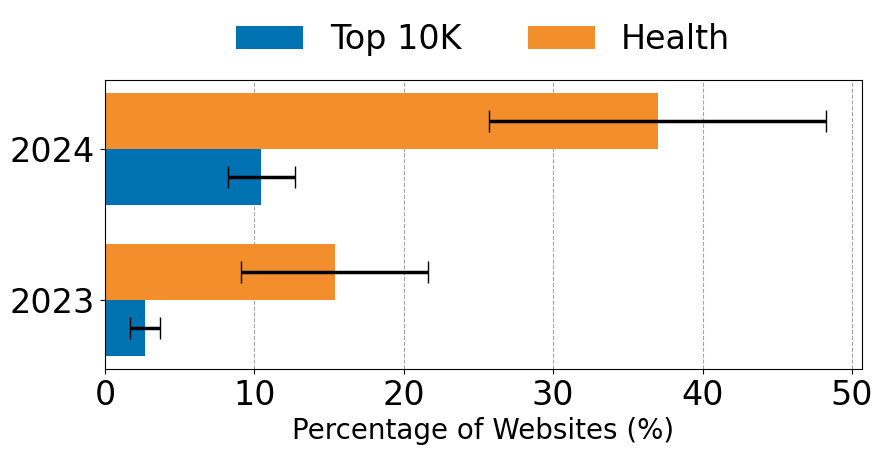

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t

def visualize_selected_match_keys_percentage_heatmap_grouped_styled(dfs, df_names=None):
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    value_presence_per_website_list = []
    error_presence_per_website_list = []  # List to store t-based confidence intervals

    for df in dfs:
        # Ensure timestamp is datetime and extract year/month info
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['month'] = df['timestamp'].dt.to_period('M')
        df['year'] = df['timestamp'].dt.to_period('Y')

        # Compute total number of unique websites per year
        total_websites_per_year = df.groupby(['year', 'website']).size().gt(0).groupby('year').sum()
        display("Total Websites: ", total_websites_per_year)

        # Explode the list of opt-in information and drop rows without data
        df_exploded = df.explode('opt_in_info').dropna(subset=['opt_in_info'])
        df_exploded[['extracted_optin_name', 'status']] = pd.DataFrame(
            df_exploded['opt_in_info'].tolist(), index=df_exploded.index
        )

        # Filter for the selected key and remove rows with missing timestamps
        df_filtered = df_exploded[df_exploded['extracted_optin_name'] == 'protecteddatamode'].dropna(subset=['timestamp'])
        
        # Count websites that have the key per year
        website_value_presence = (
            df_filtered
            .groupby(['year','website','extracted_optin_name'])
            .size()
            .unstack(fill_value=0)
            .gt(0)
            .groupby('year')
            .sum()
        )
        
        # Calculate proportion (p) and then convert to percentage
        p_df = website_value_presence.div(total_websites_per_year, axis=0)
        value_presence_per_website = p_df * 100
        display(value_presence_per_website)
        value_presence_per_website_list.append(value_presence_per_website)

        # Calculate 95% CI using t-distribution:
        # For each year, compute error = t_value * sqrt( p*(1-p)/n ) * 100
        def compute_error(p, n):
            if n <= 1:
                return 0
            t_value = t.ppf(1 - 0.05/2, df=n-1)
            return t_value * np.sqrt(p * (1 - p) / n) * 100
        
        error_df = p_df.copy()
        for year in p_df.index:
            n = total_websites_per_year.loc[year]
            error_df.loc[year] = p_df.loc[year].apply(lambda p: compute_error(p, n))
        error_presence_per_website_list.append(error_df)

    # Get all unique keys from all DataFrames
    all_keys = set()
    for vp_df in value_presence_per_website_list:
        all_keys.update(vp_df.columns)
    all_keys = sorted(list(all_keys))

    # --- Style Customizations ---
    plt.rcParams['figure.figsize'] = (9, 5)
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['ytick.labelsize'] = 24  # for y-axis (now representing years)
    plt.rcParams['xtick.labelsize'] = 24
    plt.rcParams['legend.fontsize'] = 24

    # Colors and hatches for each metric (using the two color-blind friendly colors you selected)
    colors = ["#0072B2", "#F28E2B"]
    hatches = ["...", "//", "\\\\", "xx", "oo", "OO", "..", "**"]

    # Plot settings for horizontal bars:
    num_dfs = len(dfs)
    bar_height = 0.8 / num_dfs  # height of each bar within a group
    group_gap = 0.3             # vertical gap between year groups
    bar_height = 0.425

    # Iterate through each key (each key gets its own plot)
    for key in all_keys:
        fig, ax = plt.subplots()

        # Determine all unique years (as strings) across all datasets
        year_strings_lists = [
            vp_df.index.astype(str).tolist() if vp_df is not None and vp_df.index is not None else []
            for vp_df in value_presence_per_website_list
        ]
        unique_year_strings = sorted(list(set().union(*year_strings_lists)))
        years = unique_year_strings

        if not years:
            continue  # Skip if no years to plot

        # Compute y positions for each group (one group per year)
        # For horizontal bars, we position groups along the y-axis.
        y_positions = [i * (bar_height * num_dfs + group_gap) for i in range(len(years))]

        for df_index, (vp_df, err_df) in enumerate(zip(value_presence_per_website_list, error_presence_per_website_list)):
            # Reindex for consistency and fill missing values with 0
            if key in vp_df.columns:
                data_key = vp_df[key].reindex(index=years, fill_value=0)
                error_key = err_df[key].reindex(index=years, fill_value=0)
            else:
                data_key = pd.Series(0, index=years, dtype='float64')
                error_key = pd.Series(0, index=years, dtype='float64')

            # Adjust the y positions for each dataset in the group
            bar_y_positions = [y + df_index * bar_height for y in y_positions]
            # Plot horizontal bar using ax.barh. Note we use 'xerr' since error bars are horizontal.
            ax.barh(
                bar_y_positions,
                data_key.values,
                height=bar_height,
                label=df_names[df_index],
                color=colors[df_index % len(colors)],
                # edgecolor="black",
                # hatch=hatches[df_index % len(hatches)],
                xerr=error_key.values,
                error_kw = {'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8},
                capsize=5,
            )

        # --- Formatting ---
        ax.set_xlabel("Percentage of Websites (%)", fontsize=20)
        ax.set_axisbelow(True)
        ax.xaxis.grid(True, linestyle="--", color="gray", alpha=0.7)

        # Set y-tick labels at the center of each group
        tick_positions = [y + (num_dfs * bar_height - bar_height) / 2 for y in y_positions]
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(years)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=2, frameon=False)
        plt.tight_layout()

        pdf_filename = f"plot_coresetup.pdf"
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', transparent=True)
        print(f"Plot saved as {pdf_filename}")
        plt.show()

    return value_presence_per_website_list, error_presence_per_website_list

# Replace these with your actual DataFrames
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

df1 = df1[(df1['timestamp'] >= '2023-01-01') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2023-01-01') & (df2['timestamp'] < '2025-01-01')]

# Example usage (adjust DataFrames and names as needed)
result_dfs, result_errors = visualize_selected_match_keys_percentage_heatmap_grouped_styled(
    [df1, df2],
    df_names=['Top 10K', 'Health']
)


In [25]:
top10k_websites

,plugin_name,opt_in_info,config_set_info,fbq_set_info,timestamp,website,pixel_id,year
0,[],[],[],[],2017-04-22 10:45:25,humblebundle.com,1658430177760250,2017
1,[],[],[],[],2017-04-23 18:29:56,c212.net,1164137303667517,2017
2,[],[],[],[],2017-04-25 01:58:05,statnews.com,436331036555416,2017
3,[],[],[],[],2017-04-26 22:09:03,nv.ua,621804181265771,2017
4,[],[],[],[],2017-05-01 17:55:31,humblebundle.com,1658430177760250,2017
...,...,...,...,...,...,...,...,...
89574,"[iwlbootstrapper, cookie, prohibitedsources, u...","[(iwlbootstrapper, true), (firstpartycookies, ...","[(cookie, {'fbcParamsConfig': {'params': [{'pr...",[],2024-12-21 07:10:42,axisbank.com,406603102848688,2024
89575,"[inferredevents, identity, iwlbootstrapper, co...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': None, 'di...",[],2024-12-26 07:06:27,castbox.fm,572262379840831,2024
89576,"[inferredevents, identity, iwlbootstrapper, iw...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': 'extended...","[(iwlextractors, []), (estrules, [{'condition'...",2024-12-28 05:58:48,clicrbs.com.br,871225726343984,2024
89577,"[inferredevents, identity, iwlbootstrapper, co...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': None, 'di...",[],2024-12-31 08:54:00,simplecast.com,585419305272877,2024


In [26]:
top10k_websites.iloc[-1]['fbq_set_info']

[('iwlextractors', []),
 ('estrules',
  [{'condition': {'type': 1,
     'conditions': [{'targetType': 1,
       'extractor': 2,
       'operator': 2,
       'action': 1,
       'value': 'get started'}]},
    'derived_event_name': 'Search',
    'transformations': [1],
    'rule_status': 'ACTIVE',
    'rule_id': '1315115029316638'},
   {'condition': {'type': 1,
     'conditions': [{'targetType': 1,
       'extractor': 2,
       'operator': 2,
       'action': 1,
       'value': 'start your free day trial'}]},
    'derived_event_name': 'Search',
    'transformations': [1],
    'rule_status': 'ACTIVE',
    'rule_id': '5199089910201277'},
   {'condition': {'type': 1,
     'conditions': [{'targetType': 1,
       'extractor': 2,
       'operator': 2,
       'action': 1,
       'value': 'sign in up'}]},
    'derived_event_name': 'Lead',
    'transformations': [1],
    'rule_status': 'ACTIVE',
    'rule_id': '1294126988076519'},
   {'condition': {'type': 1,
     'conditions': [{'targetType': 1,

Total Websites:  1110


derived_event_name
AddPaymentInfo           1.621622
AddToCart                9.369369
AddToWishlist            4.324324
CompleteRegistration    14.864865
Contact                  5.225225
CustomizeProduct         2.252252
Donate                   1.261261
Empty                   49.369369
FindLocation             1.891892
InitiateCheckout        12.522523
Lead                    26.036036
Purchase                11.081081
Schedule                 1.891892
Search                   3.603604
StartTrial               6.036036
SubmitApplication        5.225225
Subscribe                8.558559
ViewContent             12.162162
dtype: float64

Total Websites:  155


derived_event_name
AddPaymentInfo           1.290323
AddToCart                5.806452
AddToWishlist            1.290323
CompleteRegistration    12.258065
Contact                 14.193548
CustomizeProduct         1.935484
Donate                   8.387097
Empty                   42.580645
FindLocation             9.032258
InitiateCheckout        12.903226
Lead                    25.161290
Purchase                14.193548
Schedule                 9.677419
Search                   9.677419
StartTrial               3.870968
SubmitApplication        7.741935
Subscribe               10.322581
ViewContent             21.935484
dtype: float64

Plot saved as plot_events.pdf


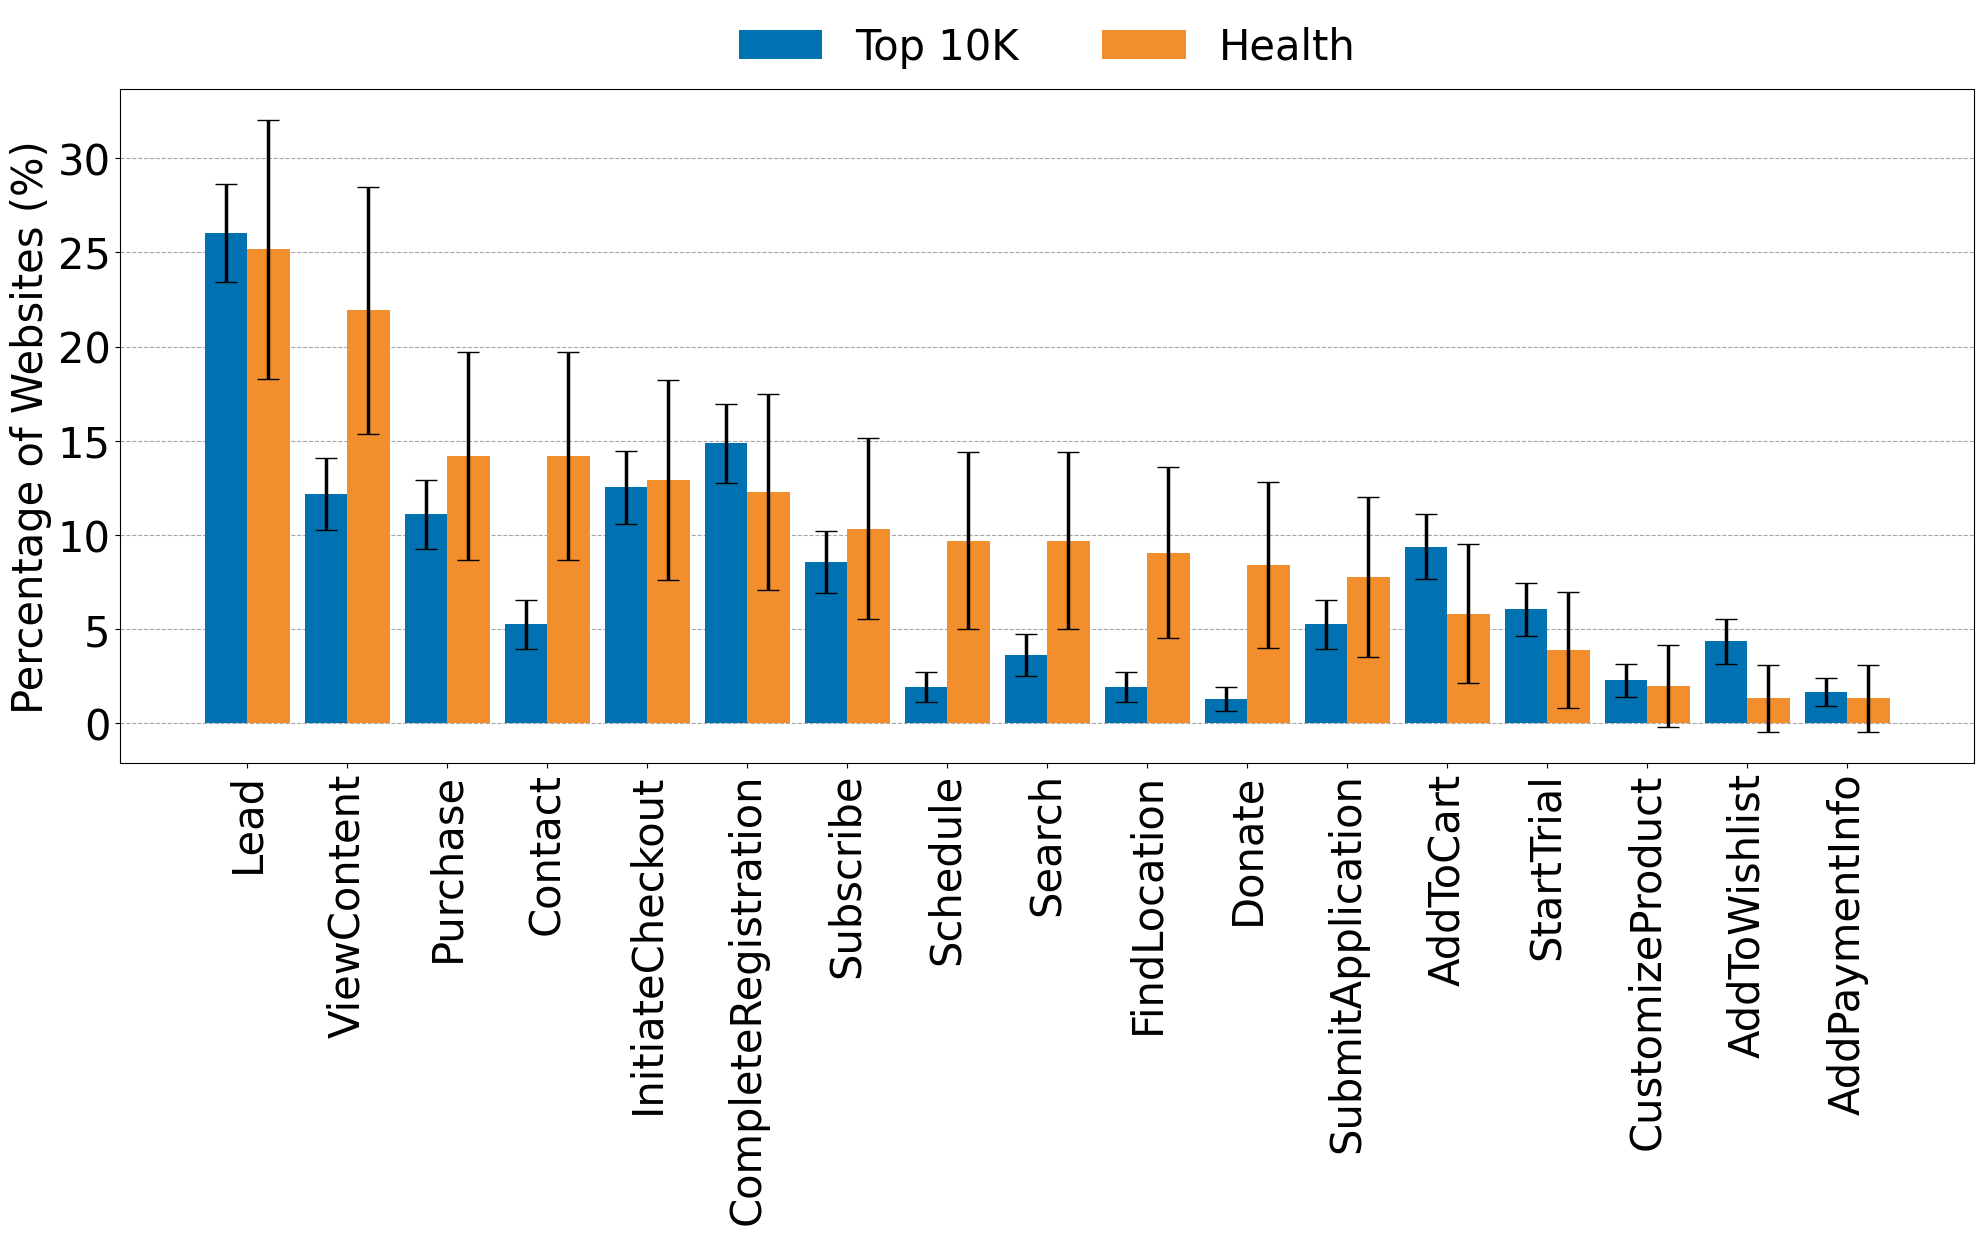

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import t
import matplotlib

def visualize_selected_match_keys_overall_single_plot(dfs, df_names=None):
    """
    Visualizes the overall percentage of websites using each selected match key (derived_event_name)
    for multiple DataFrames as a single grouped bar plot with 95% confidence intervals computed using t-scores.
    Data from all years is combined. The event named "Empty" is removed from the analysis.
    
    Args:
        dfs (list of pd.DataFrame): A list of Pandas DataFrames, each containing website data.
        df_names (list of str, optional): A list of names for each DataFrame, used in plot labels.
                                          If None, default names 'DF1', 'DF2', ... will be used.
                                          
    Returns:
        tuple: (all_keys, value_presence_overall_list) where:
               - all_keys is a sorted list of unique event keys (excluding "Empty"), sorted based on the hospital data.
               - value_presence_overall_list is a list of pd.Series containing the percentages per key.
    """
    if df_names is None:
        df_names = [f'DF{i+1}' for i in range(len(dfs))]
    if len(dfs) != len(df_names):
        raise ValueError("Length of dfs and df_names must be the same.")

    value_presence_overall_list = []
    total_websites_list = []  # overall sample sizes for CI calculation

    for df in dfs:
        # Ensure timestamp is datetime (even if we won't group by year now)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        
        # Compute overall unique websites
        total_websites = df['website'].nunique()
        total_websites_list.append(total_websites)
        
        print("Total Websites: ", total_websites)
        # Process fbq_set_info column: explode and extract keys
        df_exploded = df.explode('fbq_set_info').dropna(subset=['fbq_set_info'])
        df_exploded[['extracted_fbq_name', 'fbq_json']] = pd.DataFrame(
            df_exploded['fbq_set_info'].tolist(), index=df_exploded.index
        )
        df_filtered = df_exploded[df_exploded['extracted_fbq_name'] == 'estrules'].dropna(subset=['timestamp'])
        df_filtered['derived_event_name'] = df_filtered['fbq_json'].apply(lambda x: find_subconfig(x, 'derived_event_name'))



        # Explode the list of derived_event_name values and fill missing ones with "Empty"
        df_keys = df_filtered.explode('derived_event_name', ignore_index=False).fillna({'derived_event_name': 'Empty'})

        # df_keys['derived_event_name'].replace('Schedule', 'Average', inplace=True)
        # df_keys['derived_event_name'].replace('FindLocation', 'Average', inplace=True)
        # df_keys['derived_event_name'].replace('Search', 'Average', inplace=True)
        # df_keys['derived_event_name'].replace('Donate', 'Average', inplace=True)
        
        # For each website and key, mark True if the key appears at least once
        website_value_presence = df_keys.groupby(['website', 'derived_event_name']).size().unstack(fill_value=0).gt(0)
        
        # Calculate percentage of websites using each key
        percentage_by_key = website_value_presence.sum() / total_websites * 100
        value_presence_overall_list.append(percentage_by_key)

        display(percentage_by_key)

    # Create the union of all keys across datasets
    all_keys = set()
    for vp_series in value_presence_overall_list:
        all_keys.update(vp_series.index)
    # Remove "Empty" and convert to list
    all_keys.discard("Empty")
    all_keys = list(all_keys)
    
    # ------------------ Sorting Section Based on Hospitals ------------------
    # Find the index corresponding to the hospital dataset.
    try:
        hosp_index = df_names.index('Health')
    except ValueError:
        raise ValueError("The hospital dataset must be named 'Hospitals' in df_names for sorting.")
    
    # Get the series corresponding to Hospitals and reindex to have all keys
    hosp_series = value_presence_overall_list[hosp_index].reindex(all_keys, fill_value=0)
    # Sort the keys based on the percentage in Hospitals (highest first)
    all_keys = hosp_series.sort_values(ascending=False).index.tolist()
    # -------------------------------------------------------------------------

    # --- Style Customizations ---
    plt.rcParams['figure.figsize'] = (20, 13)      # Wider figure
    plt.rcParams['font.size'] = 12                # Base font size
    plt.rcParams['axes.labelsize'] = 25           # Axis label font size
    plt.rcParams['axes.titlesize'] = 16           # Axis title font size
    plt.rcParams['xtick.labelsize'] = 30          # X tick label font size
    plt.rcParams['ytick.labelsize'] = 30          # Y tick label font size
    plt.rcParams['legend.fontsize'] = 30          # Legend font size

    # --- Colors and hatches for each dataset ---
    # colors = ["#99d594", "#fc8d62", "#8da0cb", "#e78ac3",
    #           "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]

    # colors = ["#0072B2", "#E69F00"]
    colors = ["#0072B2", "#D55E00"]

    colors = ["#0072B2", "#F28E2B"]

# D55E00

    hatches = ["..", "//", "\\\\", "xx", "oo", "OO", "..", "**"]

    # Create x positions for each key (group)
    x = np.arange(len(all_keys))
    num_dfs = len(dfs)
    bar_width = 0.85 / num_dfs  # Width of each bar
    bar_width = 0.425

    fig, ax = plt.subplots()

    # For each dataset, plot the corresponding bar for every key with error bars
    for df_index, vp_series in enumerate(value_presence_overall_list):
        # Reindex the series so that every key appears; missing keys are set to 0.
        data = vp_series.reindex(all_keys, fill_value=0)
        total_websites = total_websites_list[df_index]
        
        # Compute error bars using t-score
        errors = []
        for key in all_keys:
            p = data.loc[key] / 100.0  # Convert percentage to proportion
            if total_websites > 1:
                t_crit = t.ppf(1 - 0.05/2, df=total_websites - 1)
                se = np.sqrt(p * (1 - p) / total_websites)
                margin = t_crit * se * 100  # Convert margin back to percentage points
            else:
                margin = 0
            errors.append(margin)
        errors = np.array(errors)

        # Offset the x positions for each dataset within each group
        offset = (df_index - num_dfs / 2) * bar_width + bar_width/2
        ax.bar(x + offset, data.values, width=bar_width,
               label=df_names[df_index],
               color=colors[df_index % len(colors)],
            #    edgecolor="black",
            #    hatch=hatches[df_index % len(hatches)],
               yerr=errors,
               capsize=5,
               error_kw = {'elinewidth': 2.5, 'ecolor': 'black', 'capsize': 8}
)

    # --- Formatting ---
    ax.set_xticks(x)
    ax.set_xticklabels(all_keys, rotation=90)
    ax.set_ylabel("Percentage of Websites (%)", fontsize=30)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", color="gray", alpha=0.7)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)

    plt.tight_layout()


    pdf_filename = "plot_events.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', 
            transparent=True)  # Keep transparency in PDF
    
    print(f"Plot saved as {pdf_filename}")
    plt.show()
    plt.show()

    return all_keys, value_presence_overall_list

# Example Usage:
# Assuming you have dataframes: top10k_websites, hospital_websites, kids_websites,
# with columns 'timestamp', 'website', 'fbq_set_info', etc.
#
# Replace these with your actual DataFrames:
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

# Optionally filter dates as desired:
df1 = df1[(df1['timestamp'] >= '2023-01-14') & (df1['timestamp'] < '2025-01-01')]
df2 = df2[(df2['timestamp'] >= '2023-01-14') & (df2['timestamp'] < '2025-01-01')]

# Call the function with two DataFrames and custom names. Make sure the hospital DataFrame is named 'Hospitals'
all_keys, result_series = visualize_selected_match_keys_overall_single_plot(
    [df1, df2],
    df_names=['Top 10K', 'Health']
)


In [28]:
import pandas as pd
import numpy as np


def compute_any_event_percentage(df, events_of_interest):
    """
    Computes the percentage of distinct websites in `df` that use
    at least one of `events_of_interest`.
    """
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    total_sites = df['website'].nunique()
    if total_sites == 0:
        return 0.0
    
    # 1) Explode fbq_set_info → extract only 'estrules' entries
    df_expl = (
        df
        .explode('fbq_set_info')
        .dropna(subset=['fbq_set_info'])
    )
    df_expl[['name', 'fbq_json']] = pd.DataFrame(
        df_expl['fbq_set_info'].tolist(), index=df_expl.index
    )
    df_e = df_expl[df_expl['name'] == 'estrules']
    
    # 2) Pull out derived_event_name
    df_e['derived_event_name'] = df_e['fbq_json'].apply(
        lambda j: find_subconfig(j, 'derived_event_name')
    )
    
    # 3) Explode that list and filter to only your four events
    df_k = (
        df_e
        .explode('derived_event_name')
        .fillna({'derived_event_name': 'Empty'})
    )
    df_sel = df_k[df_k['derived_event_name'].isin(events_of_interest)]
    
    # 4) Find how many unique websites appear here
    sites_with_any = df_sel['website'].nunique()
    
    # 5) Compute percentage
    pct = sites_with_any / total_sites * 100.0
    return pct

# ─── Example usage ────────────────────────────────────────────────────────────

# 1. Define your four key events:
selected_events = [
    'FindLocation',
    'Donate',
    'Search',
    'Schedule'
]

# 2. (Replace these with your actual DataFrames:)
df1 = top10k_websites.copy()
df2 = hospital_websites.copy()

# 3. Optionally filter dates:
# df1 = df1[(df1['timestamp'] >= '2023-01-14') & (df1['timestamp'] < '2025-01-01')]
# df2 = df2[(df2['timestamp'] >= '2023-01-14') & (df2['timestamp'] < '2025-01-01')]

# 4. Compute percentages:
pct1 = compute_any_event_percentage(df1, selected_events)
pct2 = compute_any_event_percentage(df2, selected_events)

# 5. Print results:
print(f"Top 10K sites using ANY of {selected_events}: {pct1:.2f}%")
print(f"Health sites using ANY of {selected_events}: {pct2:.2f}%")


/tmp/ipykernel_409788/4022326094.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_e['derived_event_name'] = df_e['fbq_json'].apply(


Top 10K sites using ANY of ['FindLocation', 'Donate', 'Search', 'Schedule']: 3.03%
Health sites using ANY of ['FindLocation', 'Donate', 'Search', 'Schedule']: 3.32%


/tmp/ipykernel_409788/4022326094.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_e['derived_event_name'] = df_e['fbq_json'].apply(


In [29]:
get_fbq_set_filtered(top10k_websites, 'estrules')

,plugin_name,opt_in_info,config_set_info,fbq_set_info,timestamp,website,pixel_id,year,extracted_fbq_config_name,fbq_set_list
2784,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","[(microdata, {'waitTimeMs': 500}), (prohibited...","(estrules, [])",2023-01-19 22:05:57,gmu.edu,2412859595413424,2023,estrules,[]
2788,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","[(microdata, {'waitTimeMs': 500}), (prohibited...","(estrules, [])",2023-02-01 10:45:25,haaretz.com,307252476589397,2023,estrules,[]
2790,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","[(inferredevents, {'buttonSelector': 'extended...","(estrules, [{'condition': '{""type"":1,""conditio...",2023-02-01 12:02:08,nv.ua,621804181265771,2023,estrules,"[{'condition': '{""type"":1,""conditions"":[{""targ..."
2796,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","[(microdata, {'waitTimeMs': 500}), (prohibited...","(estrules, [])",2023-02-02 16:32:08,opera-mini.net,1123357797681867,2023,estrules,[]
2797,"[inferredevents, identity, jsonldmicrodata, iw...","[(inferredevents, true), (microdatajsonld, tru...","[(microdata, {'waitTimeMs': 500}), (prohibited...","(estrules, [])",2023-02-02 19:29:09,ajc.com,812212812506283,2023,estrules,[]
...,...,...,...,...,...,...,...,...,...,...
89569,"[inferredevents, identity, iwlbootstrapper, iw...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': 'extended...","(estrules, [{'condition': {'type': 1, 'conditi...",2024-12-20 01:57:14,trendmicro.com,432148190665264,2024,estrules,"[{'condition': {'type': 1, 'conditions': [{'ta..."
89570,"[inferredevents, identity, iwlbootstrapper, iw...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': None, 'di...","(estrules, [{'condition': {'type': 1, 'conditi...",2024-12-20 01:57:18,trendmicro.com,243552383039605,2024,estrules,"[{'condition': {'type': 1, 'conditions': [{'ta..."
89571,"[inferredevents, identity, iwlbootstrapper, iw...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': None, 'di...","(estrules, [{'condition': {'type': 1, 'conditi...",2024-12-20 07:19:46,cnnindonesia.com,1047303935301449,2024,estrules,"[{'condition': {'type': 1, 'conditions': [{'ta..."
89576,"[inferredevents, identity, iwlbootstrapper, iw...","[(inferredevents, true), (iwlbootstrapper, tru...","[(inferredevents, {'buttonSelector': 'extended...","(estrules, [{'condition': {'type': 1, 'conditi...",2024-12-28 05:58:48,clicrbs.com.br,871225726343984,2024,estrules,"[{'condition': {'type': 1, 'conditions': [{'ta..."
